# End-to-end Learning with Autoencoders over Rayleigh Fading with Estimated CSI

**Author:** Yuxing Mao — *AI-Native Transceiver Design for Next-Generation Wireless Networks*

Extends the Sionna autoencoder tutorial from AWGN to block-fading Rayleigh with pilot-based
channel estimation. Ordered by dependency: **all definitions first (Part I), all experiments
after (Part II)**. `Run All` works end to end.

## Findings at a glance

Every row names the cell that measures it; nothing here is quoted from the literature. The two
poster figures (8b, 12c) run at 64,000 blocks per SNR point; the rest of the notebook runs at the
12,800-block exploratory budget.

| # | Question | Answer | Section |
|---|---|---|---|
| 1 | Does the autoencoder beat 64-QAM under AWGN? | Yes — **+0.37 dB**, from constellation shaping, repeatable at 1e-2/1e-3/1e-4 | 8b |
| 2 | Can AWGN weights transfer to Rayleigh? | **No** — BER *rises* with SNR | 11a, 11b |
| 3 | Is the cause out-of-distribution extrapolation? | **Yes, and on the input side** — clamping `no_eff` alone restores a monotonic curve with no weight changed | 11c |
| 4 | Which tail does the damage? | The **quiet** one: at 18 dB, 89% of symbols sit *below* the training window, 4.6% above | 11c-i |
| 5 | Does retraining fix it? | Yes, under estimated CSI; estimation costs +0.022 nats/bit | 12a, 12b |
| 6 | Does the autoencoder beat *classical* on the same fading channel? | **No — null result.** The 1e-4 "gain" changed sign between two runs of the same systems | 12c |
| 7 | Optimal pilot count P? | Shallow optimum at P = 4–6; P = 2 is now the worst | 13 |
| 8 | Does a CNN demapper help? | No — flat fading offers no symbol correlation | 14 |
| 9 | Is 128 hidden units too large? | Yes — 64 matches it at 27% of the parameters; 32 does not | 15 |
| 10 | Where does 1e-5 come from? | LDPC coding gain; uncoded stays far higher | 16 |
| 11 | Does the training-SNR strategy matter? | No — N0 is an explicit input | 17 |

> **Two results here overturn earlier versions of this notebook**, and both were found by adding a
> measurement rather than an argument. Row 3/4: the U-shape was blamed on an unbounded output layer
> and on deep fades; intervention (11c) showed clamping the LLRs does nothing and erasing deep
> fades makes it *worse* — the damage is on the input side and in the opposite tail. Row 9: width
> 32 was reported as nearly matching 128; that came from a single-batch training loss whose noise
> was as large as the effect, and a seeded validation BCE moved the knee to 64.

> **Reproduction note.** Section 8 is seeded, and the seeded run reproduced the previous AWGN
> weights bit-for-bit — Sections 9b, 12b, 13 and 15 came back numerically identical, so nothing
> earlier was invalidated. Where the poster run does differ from the exploratory one (8b: +0.41 →
> +0.37 dB) the weights were unchanged and only the sample size grew, so the poster number is the
> corrected one.

> **On plotted points.** Both poster cells drop any point resting on fewer than 30 block errors
> (~18% relative standard error) before measuring or drawing anything. `precision_table()` prints
> the accumulated error count per point so the truncation is auditable rather than silent.

## Design invariants worth stating up front

- **CSI never reaches the transmitter.** `h` is generated *inside* the channel function, after
  the mapper has already produced `x`. The learned constellation is a global parameter, not a
  function of any realisation of `h`.
- **Information bits are i.i.d. uniform** (`BinarySource`, p = 0.5), 750 info / 1500 coded bits
  per codeword — not a small fixed payload.
- **Pilot overhead is charged for**: `coderate_eff = coderate * (L - P) / L`, which prices in both
  the rate loss and the energy spent on pilots.
- **Channel estimation is charged for**: `no_eff` carries a `1 + 1/P` factor (Section 5, validated
  in 9b). Omitting it understates the noise by 1.76 dB at P = 2 and 0.51 dB at P = 8.
- **Comparisons are matched.** Every autoencoder-vs-classical comparison puts both systems through
  the identical channel call with the identical overhead accounting.

# Part I — Definitions

Definitions and imports only; nothing is computed here.

## 1. Imports and simulation parameters

In [1]:
# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import os
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from sionna.phy import Block
from sionna.phy.channel import AWGN
from sionna.phy.utils import ebnodb2no, expand_to_rank, sim_ber
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.mapping import Mapper, Demapper, Constellation, BinarySource

sionna.phy.config.seed = 42  # Set seed for reproducible random number generation

%matplotlib inline

In [2]:
###############################################
# SNR range for evaluation and training [dB]
###############################################
ebno_db_min = 4.0
ebno_db_max = 8.0

###############################################
# Modulation and coding configuration
###############################################
num_bits_per_symbol = 6  # Baseline is 64-QAM
modulation_order = 2**num_bits_per_symbol
coderate = 0.5  # Coderate for the outer code
n = 1500  # Codeword length [bit]. Must be a multiple of num_bits_per_symbol
num_symbols_per_codeword = n // num_bits_per_symbol  # Number of modulated baseband symbols per codeword
k = int(n * coderate)  # Number of information bits per codeword

###############################################
# Training configuration
###############################################
num_training_iterations_conventional = 10000  # Number of training iterations for conventional training
training_batch_size = 128  # Training batch size
model_weights_path_conventional_training = "awgn_autoencoder_weights_conventional_training"  # Filename to save the autoencoder weights once conventional training is done

###############################################
# Rayleigh retraining configuration
###############################################
# The block-fading waterfall sits well above the AWGN one, so retraining uses its own SNR range.
rayleigh_ebno_db_min = 8.0
rayleigh_ebno_db_max = 16.0
rayleigh_training_iterations = 3000

## 2. Neural demapper and end-to-end systems (MLP)

`NeuralDemapper` maps `[Re(y), Im(y), log10(N0)]` to one LLR **per bit**, and processes each
symbol **independently** — `nn.Linear` acts on the last axis only, so the 250 symbols of a
codeword never interact. This matches the optimal APP demapper, which is also per-symbol.

Layer sizes: input **3** (physics: a complex sample split into real/imag, plus noise power —
the same `y` implies completely different LLRs at different N0), hidden **128 x 2**
(tutorial default; see Section 15), output **6** (one LLR per bit of a 64-QAM symbol).
The `width` argument is parameterised for the capacity study.

In [3]:
class NeuralDemapper(nn.Module):
    """Neural network-based demapper with three dense layers and ReLU activation.

    width: hidden layer size (default 128, the tutorial's original value).
    """

    def __init__(self, width=128):
        super().__init__()
        self._dense_1 = nn.Linear(3, width)
        self._dense_2 = nn.Linear(width, width)
        self._dense_3 = nn.Linear(width, num_bits_per_symbol)  # Output LLRs for every bit

    def forward(self, y, no):
        # Using log10 scale helps with the performance
        no_db = torch.log10(no)

        # AWGN passes no as [batch size, 1] and needs broadcasting.
        # Rayleigh passes a per-symbol no_eff that is already [batch size, num_symbols_per_codeword].
        if no_db.shape[1] == 1:
            no_db = no_db.expand(-1, num_symbols_per_codeword)

        z = torch.stack([y.real, y.imag, no_db], dim=2)

        llr = F.relu(self._dense_1(z))
        llr = F.relu(self._dense_2(llr))
        llr = self._dense_3(llr)

        return llr

In [4]:
class E2ESystemConventionalTraining(nn.Module):
    """End-to-end communication system for conventional training.
    
    This system transmits bits modulated using a trainable constellation over
    an AWGN channel. The receiver uses a neural network-based demapper.
    """

    def __init__(self, training, width=128):
        super().__init__()
        
        self._training = training
        
        ################
        ## Transmitter
        ################
        self._binary_source = BinarySource()
        # To reduce the computational complexity of training, the outer code is not used when training
        if not self._training:
            # num_bits_per_symbol is required for the interleaver
            self._encoder = LDPC5GEncoder(k, n, num_bits_per_symbol)
        
        # Trainable constellation
        # We initialize a custom constellation with QAM points
        qam_points = Constellation("qam", num_bits_per_symbol).points
        self.points_r = nn.Parameter(qam_points.real.clone())
        self.points_i = nn.Parameter(qam_points.imag.clone())

        self.constellation = Constellation("custom",
                                           num_bits_per_symbol,
                                           points=torch.complex(self.points_r, self.points_i),
                                           normalize=True,
                                           center=True)
       
        
        self._mapper = Mapper(constellation=self.constellation)
        
        ################
        ## Channel
        ################
        self._channel = AWGN()
        
        ################
        ## Receiver
        ################
        # We use the previously defined neural network for demapping.
        # width is parameterised for the Section 15 capacity study.
        self._demapper = NeuralDemapper(width=width)
        # To reduce the computational complexity of training, the outer code is not used when training
        if not self._training:
            self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)

    def forward(self, batch_size, ebno_db):
        
        # Update constellation points from trainable parameters (creates fresh graph)
        self.constellation.points = torch.complex(self.points_r, self.points_i)

        # If `ebno_db` is a scalar, a tensor with shape [batch size] is created
        if ebno_db.dim() == 0:
            ebno_db = ebno_db.expand(batch_size)
        no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
        no = expand_to_rank(no, 2)
        
        ################
        ## Transmitter
        ################
        # Outer coding is only performed if not training
        if self._training:
            c = self._binary_source([batch_size, n])
        else:
            b = self._binary_source([batch_size, k])
            c = self._encoder(b)
        # Modulation
        x = self._mapper(c)  # x [batch size, num_symbols_per_codeword]
        
        ################
        ## Channel
        ################
        y = self._channel(x, no)  # [batch size, num_symbols_per_codeword]
        
        ################
        ## Receiver
        ################
        llr = self._demapper(y, no)
        llr = llr.reshape(batch_size, n)
        # If training, outer decoding is not performed and the BCE is returned
        if self._training:
            loss = F.binary_cross_entropy_with_logits(llr, c)
            return loss
        else:
            # Outer decoding
            b_hat = self._decoder(llr)
            return b, b_hat  # Ground truth and reconstructed information bits returned for BER/BLER computation

## 3. Utilities — training loop, save / load weights, reporting

`train()` is the single retraining loop used by every Rayleigh experiment (Sections 12, 13, 14,
17); before it existed the same twelve lines were copy-pasted five times.

`eval_bce()` matters more than it looks. The obvious thing — reporting `loss.item()` from the
last training step — is a **single-batch** estimate whose noise can exceed the effect being
measured (the width-32 vs width-64 gap in Section 15, for example). `eval_bce()` averages over a
fixed, seeded set of batches so that two configurations are compared on identical noise draws.

`load_weights()` needs `strict=False` because `LDPC5GEncoder` / `LDPC5GDecoder` are only built
when `training=False`, so a checkpoint saved in training mode legitimately lacks those keys. That
same flag would also happily accept a checkpoint whose demapper does not match at all, leaving
the network on its random initialisation — which produces symptoms almost identical to the
Section 11 failure and is very hard to track down. The demapper and constellation tensors are
therefore checked explicitly.

The last cell of this section holds the **poster-figure helpers** used by Sections 8b and 12c:
print styling, the accuracy axis, the measured-gap annotation, and `precision_table()`, which
reports how many block errors each point on a curve actually accumulated. None of it touches a
simulation result.

In [5]:
def conventional_training(model):
    """Train the model using conventional SGD with backpropagation."""
    # Optimizer used to apply gradients
    optimizer = torch.optim.Adam(model.parameters())
    device = sionna.phy.config.device
    
    for i in range(num_training_iterations_conventional):
        optimizer.zero_grad()
        # Sampling a batch of SNRs
        ebno_db = torch.empty(training_batch_size, device=device).uniform_(ebno_db_min, ebno_db_max)
        # Forward pass
        loss = model(training_batch_size, ebno_db)
        # Computing and applying gradients
        loss.backward()
        optimizer.step()
        # Printing periodically the progress
        if i % 100 == 0:
            print(f'Iteration {i}/{num_training_iterations_conventional}  BCE: {loss.item():.4f}', end='\r')
    print()
    model.eval()
    optimizer.zero_grad(set_to_none=True)

In [6]:
def save_weights(model, model_weights_path):
    m = getattr(model, "_orig_mod", model)
    torch.save(m.state_dict(), model_weights_path)

In [7]:
def load_weights(model, model_weights_path, verbose=False):
    """Load and set weights of a model.

    strict=False is required: the LDPC encoder/decoder only exist when training=False,
    so a checkpoint saved in training mode legitimately lacks those keys. Because that
    also hides a genuinely mismatched checkpoint, the tensors that must be restored
    (demapper + constellation) are verified explicitly.
    """
    device = sionna.phy.config.device
    state = torch.load(model_weights_path, map_location=device)
    incompatible = model.load_state_dict(state, strict=False)

    own = set(model.state_dict().keys())
    loaded = own & set(state.keys())
    must_load = {key for key in own
                 if key.startswith('_demapper.') or key.startswith('points_')}
    not_loaded = sorted(must_load - loaded)
    if not_loaded:
        raise RuntimeError(
            f"'{model_weights_path}': {len(not_loaded)} demapper/constellation tensor(s) were "
            f"NOT restored, e.g. {not_loaded[:3]}. The model would silently run on its random "
            f"initialisation. Check that the checkpoint matches this architecture.")
    if verbose:
        print(f"{model_weights_path}: restored {len(loaded)}/{len(own)} tensors "
              f"({len(incompatible.unexpected_keys)} unexpected in file)")

    # Update the constellation points from the loaded parameters
    model.constellation.points = torch.complex(model.points_r, model.points_i)

In [8]:
def set_seed(seed=42):
    """Seed both RNGs.

    sionna.phy.config.seed does not cover the torch.randn calls that generate the fading
    coefficients in this notebook, so the torch generator has to be seeded as well.
    """
    sionna.phy.config.seed = seed
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train(model, iterations, ebno_lo, ebno_hi, lr=1e-3, batch_size=128,
          clip=1.0, log_every=500, label=''):
    """Shared training loop for every retraining experiment.

    ebno_lo == ebno_hi trains at a single fixed SNR (used by the Section 17 comparison).
    clip=None disables gradient clipping; the Rayleigh experiments keep it because a deep
    fade can otherwise produce an unbounded gradient step.
    Returns the smoothed training loss history.
    """
    device = sionna.phy.config.device
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    history = []
    running = None
    for it in range(iterations):
        if ebno_lo == ebno_hi:
            ebno_db = torch.full((batch_size,), float(ebno_lo), device=device)
        else:
            ebno_db = torch.empty(batch_size, device=device).uniform_(ebno_lo, ebno_hi)
        optimizer.zero_grad()
        loss = model(batch_size, ebno_db)
        loss.backward()
        if clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        running = loss.item() if running is None else 0.99 * running + 0.01 * loss.item()
        history.append(running)
        if log_every and it % log_every == 0:
            print(f"  {label}it {it}/{iterations}: BCE(smoothed)={running:.4f}", end='\r')
    print(f"  {label}it {iterations}/{iterations}: BCE(smoothed)={running:.4f}")
    model.eval()
    optimizer.zero_grad(set_to_none=True)
    return history


@torch.no_grad()
def eval_bce(model, ebno_lo, ebno_hi, num_batches=32, batch_size=128, seed=1234):
    """Average BCE over a fixed, seeded set of batches.

    A single training-step loss is far too noisy to compare configurations with; reseeding
    per call means two models see the same bits, the same fades and the same noise.
    """
    device = sionna.phy.config.device
    was_training = model._training
    rng_state = torch.get_rng_state()          # do not disturb the caller's RNG stream
    model._training = True                     # returns the BCE instead of decoded bits
    model.eval()
    try:
        set_seed(seed)
        total = 0.0
        for _ in range(num_batches):
            if ebno_lo == ebno_hi:
                ebno_db = torch.full((batch_size,), float(ebno_lo), device=device)
            else:
                ebno_db = torch.empty(batch_size, device=device).uniform_(ebno_lo, ebno_hi)
            total += model(batch_size, ebno_db).item()
    finally:
        model._training = was_training
        torch.set_rng_state(rng_state)
    return total / num_batches


def snr_at_ber(ebno_dbs, ber, target=1e-3):
    """Eb/N0 at which a BER curve crosses `target`, by linear interpolation in log10(BER).

    Returns nan if the curve never crosses the target inside the simulated range, so a gap
    is never reported from an extrapolation.
    """
    ebno_dbs = np.asarray(ebno_dbs, dtype=float)
    ber = np.asarray(ber, dtype=float)
    ok = ber > 0
    x, y = ebno_dbs[ok], np.log10(ber[ok])
    t = np.log10(target)
    for i in range(len(x) - 1):
        if (y[i] - t) * (y[i + 1] - t) <= 0 and y[i] != y[i + 1]:
            return x[i] + (t - y[i]) * (x[i + 1] - x[i]) / (y[i + 1] - y[i])
    return float('nan')

In [44]:
# ---------------------------------------------------------------
# Poster-figure helpers (used by Sections 8b and 12c).
# Presentation only - nothing here changes a simulation result.
# ---------------------------------------------------------------
POSTER_RC = {
    'savefig.dpi':      300,     # raster copy; the PDF companion is what goes to the printer
    'savefig.bbox':     'tight',
    'figure.dpi':       110,     # on-screen preview only
    'font.size':        12,
    'axes.titlesize':   16,
    'axes.labelsize':   14,
    'legend.fontsize':  12,
    'xtick.labelsize':  12,
    'ytick.labelsize':  12,
    'lines.linewidth':  2,
    'lines.markersize': 8,
    'axes.grid':        True,
    'grid.alpha':       0.35,
}


def add_accuracy_axis(ax, label='bit accuracy  (1 - BER)'):
    """Mirror a log-scale BER axis as an accuracy axis on the right.

    1 - BER cannot be plotted directly: at BER 1e-5 it equals 0.99999, so every curve
    collapses onto y = 1 on a linear axis and onto y = 0 on a log axis. Relabelling the
    existing BER axis costs nothing and distorts nothing - it is the same curve, read
    the other way round. Call this AFTER the y limits are final.
    """
    ax2 = ax.twinx()
    ax2.set_yscale('log')
    ax2.set_ylim(ax.get_ylim())
    ax2.set_yticks([1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6])
    ax2.set_yticklabels(['90%', '99%', '99.9%', '99.99%', '99.999%', '99.9999%'])
    ax2.minorticks_off()
    ax2.grid(False)
    ax2.set_ylabel(label)
    return ax2


def annotate_gap(ax, x_a, x_b, y, fmt='{:.2f} dB', color='0.25'):
    """Horizontal double arrow between two curve crossings, labelled with the gap."""
    if x_a is None or x_b is None or np.isnan(x_a) or np.isnan(x_b):
        return
    ax.annotate('', xy=(x_a, y), xytext=(x_b, y),
                arrowprops=dict(arrowstyle='<->', color=color, lw=1.8))
    # The label sits beside the arrow, not on top of it. Centring it covers the arrow
    # completely whenever the gap is short, which is exactly when a reader most needs to
    # see what the number refers to. Offsetting it vertically is no better here: the two
    # curves are under one decade apart at the annotated BER, so a box above grazes the
    # upper curve and a box below grazes the lower one. Outboard of the right arrowhead
    # is above both curves and clear of the legend. Offset in points, so it holds on log
    # and linear axes alike.
    ax.annotate(fmt.format(abs(x_b - x_a)), xy=(max(x_a, x_b), y),
                xytext=(9, 0), textcoords='offset points',
                ha='left', va='center', fontsize=13, color='0.15',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.7', alpha=0.92))


def precision_table(ebno_dbs, bler, batch_size, max_mc_iter, target_errors, label):
    """How much statistical weight does each point on the curve actually carry?

    sim_ber stops a point at `target_errors` block errors or at `max_mc_iter` batches,
    whichever comes first. A point that hit the cap simulated the full budget, so its
    block-error count is exactly bler * budget; a point that hit the target has at least
    `target_errors`. Relative standard error goes as 1/sqrt(#errors) - it depends on the
    number of errors observed, not on the number of bits simulated, which is why the
    lowest points on a curve are always the weakest ones and never the strongest.
    """
    budget = batch_size * max_mc_iter
    print(f"\n{label}   (budget {budget:,} blocks/point, target {target_errors} block errors)")
    print(f"{'Eb/N0':>7} | {'BLER':>10} | {'block errors':>13} | {'rel. std err':>12} | status")
    print('-' * 76)
    for e, bl in zip(np.asarray(ebno_dbs), np.asarray(bler)):
        if bl <= 0:
            print(f"{e:>7.2f} | {bl:>10.3e} | {'0':>13} | {'n/a':>12} | no errors - unusable")
            continue
        capped = bl * budget < target_errors
        errs = bl * budget if capped else float(target_errors)
        shown = f"{errs:.0f}" if capped else f">={errs:.0f}"
        status = 'budget-capped' if capped else 'target reached'
        print(f"{e:>7.2f} | {bl:>10.3e} | {shown:>13} | {1 / np.sqrt(max(errs, 1.0)):>11.1%} | {status}")

def block_errors(bler, batch_size, max_mc_iter, target_errors):
    """Block errors actually accumulated at each point (see precision_table)."""
    budget = batch_size * max_mc_iter
    bler = np.asarray(bler, dtype=float)
    capped = bler * budget < target_errors
    return np.where(bler <= 0, 0.0, np.where(capped, bler * budget, float(target_errors)))


def reliable_mask(bler, batch_size, max_mc_iter, target_errors, min_errors=30):
    """Points carrying enough block errors to be worth printing.

    Precision goes as 1/sqrt(#block errors), and bit errors inside a failed codeword are
    strongly correlated, so the block-error count - not the bit count - sets the effective
    sample size of a BER point too. min_errors=30 is about 18% relative standard error.

    A poster is the wrong place for points that rest on three or four errors: they wander
    by a factor of two and read as structure. Curves are truncated here rather than being
    drawn and then explained away.
    """
    return block_errors(bler, batch_size, max_mc_iter, target_errors) >= min_errors

## 4. Classical baseline (AWGN)

64-QAM + Gray labelling + **APP demapping** + LDPC, with no trainable parameters. Under AWGN the
APP demapper is exactly optimal for this constellation, so Section 8b measures pure
constellation-shaping gain and nothing else.

The matched fading baseline lives in Section 5 (`BaselinePilotCSI`) because it needs the
block-fading channel function defined there. Comparing the autoencoder against a baseline on a
*different* channel is the easiest way to manufacture a gain that is not real, so every
comparison in this notebook puts both systems through the identical channel call.

In [10]:
class Baseline(nn.Module):
    """Baseline system using QAM with Gray labeling and conventional demapping."""

    def __init__(self):
        super().__init__()
        
        ################
        ## Transmitter
        ################
        self._binary_source = BinarySource()
        self._encoder = LDPC5GEncoder(k, n, num_bits_per_symbol)
        constellation = Constellation("qam", num_bits_per_symbol)
        self.constellation = constellation
        self._mapper = Mapper(constellation=constellation)
        
        ################
        ## Channel
        ################
        self._channel = AWGN()
        
        ################
        ## Receiver
        ################
        self._demapper = Demapper("app", constellation=constellation)
        self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)

    def forward(self, batch_size, ebno_db):
        # If `ebno_db` is a scalar, a tensor with shape [batch size] is created
        if ebno_db.dim() == 0:
            ebno_db = ebno_db.expand(batch_size)
        no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
        no = expand_to_rank(no, 2)
        
        ################
        ## Transmitter
        ################
        b = self._binary_source([batch_size, k])
        c = self._encoder(b)
        # Modulation
        x = self._mapper(c)  # x [batch size, num_symbols_per_codeword]
        
        ################
        ## Channel
        ################
        y = self._channel(x, no)  # [batch size, num_symbols_per_codeword]
        
        ################
        ## Receiver
        ################
        llr = self._demapper(y, no)
        # Outer decoding
        b_hat = self._decoder(llr)
        return b, b_hat  # Ground truth and reconstructed information bits returned for BER/BLER computation

## 5. Block-fading channel with pilot-based CSI

Frame structure: `h` is constant over `L = 25` symbols and i.i.d. across frames. The first `P`
symbols of each frame are unit-modulus pilots; the LS estimate is
`h_hat = (1/P) * sum(conj(x_p) * y_p)` with error variance `N0/P` (verified in Section 9a).

Unit-modulus pilots are used deliberately so that the LS estimate reduces to a simple mean —
picking pilots from the 64-QAM constellation would break that.

### The effective noise after equalisation

Zero-forcing with an *estimated* channel does not simply scale the noise. Writing `h_hat = h + e`
with `e ~ CN(0, N0/P)`:

```
z = y / h_hat = x + (n - e*x) / h_hat
Var[z - x | h_hat] = N0 * (1 + E|x|^2 / P) / |h_hat|^2 = N0 * (1 + 1/P) / |h_hat|^2
```

for the power-normalised constellation. The `1 + 1/P` term is the price of estimation, and it is
**P-dependent**: 1.76 dB at P = 2, 0.97 dB at P = 4, 0.51 dB at P = 8. Dropping it would hand the
demapper a systematically over-confident noise estimate and would flatter small P — precisely the
variable Section 13 sweeps. Section 9b verifies the formula against a Monte Carlo. With perfect
CSI there is no estimation error and the factor is 1.

The equaliser itself is left as zero-forcing on purpose: `y / h_hat` is unbounded as
`|h_hat| -> 0`, and that unboundedness is the subject of Sections 11 and 11c.

In [11]:
device = sionna.phy.config.device
print('device =', device)

device = cpu


In [12]:
def make_rayleigh_block_frame(x_data, P, L, no, device, perfect_csi=False):
    """
    x_data: [B, num_data_symbols] complex
    no:     scalar or [B,1] noise power
    perfect_csi=True uses the true h (upper-bound reference); False uses the pilot estimate h_hat
    returns z, no_eff, h, h_hat, num_frames, pad
    """
    B, num_data = x_data.shape
    data_per_frame = L - P
    num_frames = (num_data + data_per_frame - 1) // data_per_frame

    # --- one independent h per frame ---
    std = 0.5 ** 0.5
    h = torch.complex(
        torch.randn(B, num_frames, 1, device=device) * std,
        torch.randn(B, num_frames, 1, device=device) * std,
    )  # [B, F, 1]

    # --- split data symbols into frames ---
    pad = num_frames * data_per_frame - num_data
    x_padded = F.pad(x_data, (0, pad))
    x_framed = x_padded.reshape(B, num_frames, data_per_frame)  # [B, F, data_per_frame]

    if not torch.is_tensor(no):
        no = torch.tensor(float(no), device=device)
    no = no.reshape(-1, 1, 1) if no.ndim >= 1 else no.reshape(1, 1, 1)  # [B,1,1] or [1,1,1] for broadcasting
    n_std = (no / 2.0).sqrt()

    def cn(shape):  # complex Gaussian noise CN(0, no)
        return torch.complex(torch.randn(shape, device=device) * n_std,
                             torch.randn(shape, device=device) * n_std)

    # --- pilot segment: x_p = 1+0j, same h, estimate h_hat ---
    x_pilot = torch.ones(B, num_frames, P, device=device, dtype=x_data.dtype)  # unit modulus
    y_pilot = h * x_pilot + cn((B, num_frames, P))
    # LS estimate: h_hat = (1/P) sum conj(x_p) y_p (mean for unit-modulus pilots)
    h_hat = (torch.conj(x_pilot) * y_pilot).mean(dim=2, keepdim=True)  # [B, F, 1]

    # --- data segment: through the true h ---
    y_framed = h * x_framed + cn((B, num_frames, data_per_frame))

    # --- equalize with h_hat (or true h for upper-bound reference) ---
    h_use = h if perfect_csi else h_hat
    z_framed = y_framed / h_use

    # Effective noise seen by the demapper. With h_hat = h + e, e ~ CN(0, no/P):
    #   z - x = (n - e*x) / h_hat   ->   Var = no*(1 + E|x|^2/P) / |h_hat|^2
    # E|x|^2 = 1 for the normalised constellation. Perfect CSI has no estimation error.
    # Omitting this factor understates the noise by 1.76/0.97/0.51 dB at P = 2/4/8.
    est_err_factor = 1.0 if perfect_csi else (1.0 + 1.0 / P)
    no_eff_framed = est_err_factor * no / (h_use.real ** 2 + h_use.imag ** 2)
    no_eff_framed = no_eff_framed.expand(-1, -1, data_per_frame)

    # --- flatten to symbol stream, drop padding ---
    z = z_framed.reshape(B, -1)[:, :num_data]
    no_eff = no_eff_framed.reshape(B, -1)[:, :num_data]

    return z, no_eff, h, h_hat, num_frames, pad

In [13]:
class E2ESystemPilotCSI(E2ESystemConventionalTraining):
    """Block-fading + pilot-estimated CSI. Inherits TX/RX, reuses AWGN weights."""

    def __init__(self, P, L, training=False, perfect_csi=False):
        super().__init__(training=training)
        self.P = P
        self.L = L
        self.perfect_csi = perfect_csi

    def forward(self, batch_size, ebno_db):
        self.constellation.points = torch.complex(self.points_r, self.points_i)
        if ebno_db.dim() == 0:
            ebno_db = ebno_db.expand(batch_size)

        # key: fold pilot overhead into the effective code rate
        coderate_eff = coderate * (self.L - self.P) / self.L
        no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate_eff)
        no = expand_to_rank(no, 2)

        # transmitter
        if self._training:
            c = self._binary_source([batch_size, n])
        else:
            b = self._binary_source([batch_size, k])
            c = self._encoder(b)
        x = self._mapper(c)   # [B, 250]

        # block-fading channel + pilot estimation (reuse the verified helper)
        no_scalar = no[:, :1]  # [B,1]
        z, no_eff, h, h_hat, nf, pad = make_rayleigh_block_frame(
            x, P=self.P, L=self.L, no=no_scalar,
            device=x.device, perfect_csi=self.perfect_csi)

        # receiver
        llr = self._demapper(z, no_eff)
        llr = llr.reshape(batch_size, n)

        if self._training:
            return F.binary_cross_entropy_with_logits(llr, c)
        else:
            b_hat = self._decoder(llr)
            return b, b_hat

In [14]:
class BaselinePilotCSI(nn.Module):
    """Classical reference on exactly the SAME channel as E2ESystemPilotCSI.

    64-QAM + Gray labelling + APP demapping + LDPC, over block fading with pilot-estimated
    CSI and identical pilot-overhead accounting. Everything except the transmitter
    constellation and the demapper is shared with the autoencoder, so any difference in
    BER is attributable to those two blocks.

    Note the subtlety this baseline exposes. With *perfect* CSI, (y/h, N0/|h|^2) is a
    sufficient statistic and APP demapping is optimal, so the baseline is unbeatable. With
    *estimated* CSI it no longer is: the residual (n - e*x)/h_hat is neither Gaussian nor
    independent of the transmitted symbol, so an APP demapper fed a Gaussian no_eff is
    running on a mismatched model. That mismatch is the room a learned demapper can exploit,
    and 12c measures whether it actually does.
    """

    def __init__(self, P, L, perfect_csi=False):
        super().__init__()
        self.P = P
        self.L = L
        self.perfect_csi = perfect_csi

        self._binary_source = BinarySource()
        self._encoder = LDPC5GEncoder(k, n, num_bits_per_symbol)
        constellation = Constellation("qam", num_bits_per_symbol)
        self.constellation = constellation
        self._mapper = Mapper(constellation=constellation)
        self._demapper = Demapper("app", constellation=constellation)
        self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)

    def forward(self, batch_size, ebno_db):
        if ebno_db.dim() == 0:
            ebno_db = ebno_db.expand(batch_size)

        # identical pilot-overhead accounting as E2ESystemPilotCSI
        coderate_eff = coderate * (self.L - self.P) / self.L
        no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate_eff)
        no = expand_to_rank(no, 2)

        b = self._binary_source([batch_size, k])
        c = self._encoder(b)
        x = self._mapper(c)

        # the very same channel call the autoencoder uses
        z, no_eff, h, h_hat, nf, pad = make_rayleigh_block_frame(
            x, P=self.P, L=self.L, no=no[:, :1],
            device=x.device, perfect_csi=self.perfect_csi)

        llr = self._demapper(z, no_eff)
        b_hat = self._decoder(llr)
        return b, b_hat

In [15]:
class E2ESystemPilotClamped(E2ESystemPilotCSI):
    """Section 11c intervention: identical weights, identical channel, one thing changed.

    Section 11 attributes the U-shaped BER to a ReLU network extrapolating outside the input
    range it saw during AWGN training, whose unbounded output layer then emits large, confident
    and wrong LLRs that LDPC propagates. Retraining also fixes the curve, but retraining changes
    everything at once and therefore cannot isolate a cause.

    Each knob changes exactly one thing and leaves every weight untouched:

      llr_max         clamp every LLR to +/- llr_max. Tests the 'unbounded output layer' half:
                      the network still extrapolates, it just cannot shout.
      fade_ratio_max  erase symbols whose effective noise exceeds fade_ratio_max * no - the deep
                      fades - by forcing their LLRs to 0. Tests the stronger claim that on those
                      symbols the network's output is worse than no information at all.
                      no_eff / no is (1 + 1/P) / |h_use|^2, so the threshold is a fade depth.
      no_db_clamp     clamp the noise power *reported to the demapper* into the window the
                      network actually saw during AWGN training. This is the INPUT-side
                      intervention, and it is the one that matches what Section 11 actually
                      accuses: the text blames the input range, so the test has to act on the
                      input. The channel is untouched - only what the demapper is told changes.

    The first run of 11c falsified the output-side knobs: llr_max barely moved the curve and
    fade erasure made high SNR worse. no_db_clamp was added afterwards to test the claim the
    section actually makes.
    """

    def __init__(self, P, L, llr_max=None, fade_ratio_max=None, no_db_clamp=False, **kwargs):
        super().__init__(P, L, **kwargs)
        self.llr_max = llr_max
        self.fade_ratio_max = fade_ratio_max
        self.no_db_clamp = no_db_clamp

        # The AWGN training window in linear noise power. ebno_db_min gives the LARGEST
        # no (noisiest point seen in training), ebno_db_max the smallest.
        _hi = ebnodb2no(torch.tensor([float(ebno_db_min)]), num_bits_per_symbol, coderate)
        _lo = ebnodb2no(torch.tensor([float(ebno_db_max)]), num_bits_per_symbol, coderate)
        self.no_train_hi = float(_hi.reshape(-1)[0])
        self.no_train_lo = float(_lo.reshape(-1)[0])

    def forward(self, batch_size, ebno_db):
        self.constellation.points = torch.complex(self.points_r, self.points_i)
        if ebno_db.dim() == 0:
            ebno_db = ebno_db.expand(batch_size)

        coderate_eff = coderate * (self.L - self.P) / self.L
        no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate_eff)
        no = expand_to_rank(no, 2)

        if self._training:
            c = self._binary_source([batch_size, n])
        else:
            b = self._binary_source([batch_size, k])
            c = self._encoder(b)
        x = self._mapper(c)

        z, no_eff, h, h_hat, nf, pad = make_rayleigh_block_frame(
            x, P=self.P, L=self.L, no=no[:, :1],
            device=x.device, perfect_csi=self.perfect_csi)

        # ---- input-side intervention: what the demapper is TOLD about the noise ----
        # The channel is unchanged; only the third input feature is restricted to the
        # range the network was trained on. Outside that range a ReLU net extrapolates.
        no_eff_told = no_eff.clamp(self.no_train_lo, self.no_train_hi) if self.no_db_clamp else no_eff

        llr = self._demapper(z, no_eff_told)     # [B, num_symbols_per_codeword, num_bits_per_symbol]

        # ---- output-side interventions ----
        if self.llr_max is not None:
            llr = llr.clamp(-self.llr_max, self.llr_max)
        if self.fade_ratio_max is not None:
            deep_fade = no_eff > self.fade_ratio_max * no[:, :1]      # [B, num_symbols]
            llr = llr.masked_fill(deep_fade.unsqueeze(-1), 0.0)       # erasure: LLR = 0

        llr = llr.reshape(batch_size, n)

        if self._training:
            return F.binary_cross_entropy_with_logits(llr, c)
        else:
            b_hat = self._decoder(llr)
            return b, b_hat

## 6. CNN demapper

1-D convolutions with a receptive field spanning neighbouring symbols inside a frame.
Input channels: `[Re(z), Im(z), Re(h_hat), Im(h_hat), log10(no_eff)]`.

In [16]:
def make_frame_cnn(x_data, P, L, no, device, perfect_csi=False):
    """Return a frame-structured tensor for the CNN (not flattened).
    features: [B, num_frames, data_per_frame, C]  C=5: Re(z),Im(z),Re(h_hat),Im(h_hat),log10(no_eff)
    """
    B, num_data = x_data.shape
    dpf = L - P
    nf = (num_data + dpf - 1) // dpf
    std = 0.5 ** 0.5
    h = torch.complex(torch.randn(B, nf, 1, device=device) * std,
                      torch.randn(B, nf, 1, device=device) * std)
    pad = nf * dpf - num_data
    x_framed = F.pad(x_data, (0, pad)).reshape(B, nf, dpf)

    if not torch.is_tensor(no):
        no = torch.tensor(float(no), device=device)
    no = no.reshape(-1, 1, 1) if no.ndim >= 1 else no.reshape(1, 1, 1)
    n_std = (no / 2.0).sqrt()
    def cn(shape):
        return torch.complex(torch.randn(shape, device=device) * n_std,
                             torch.randn(shape, device=device) * n_std)

    x_pilot = torch.ones(B, nf, P, device=device, dtype=x_data.dtype)
    y_pilot = h * x_pilot + cn((B, nf, P))
    h_hat = (torch.conj(x_pilot) * y_pilot).mean(dim=2, keepdim=True)  # [B,nf,1]

    y_framed = h * x_framed + cn((B, nf, dpf))
    h_use = h if perfect_csi else h_hat
    z = y_framed / h_use                                    # [B,nf,dpf]
    # same estimation-error correction as make_rayleigh_block_frame (see Section 5)
    est_err_factor = 1.0 if perfect_csi else (1.0 + 1.0 / P)
    no_eff = est_err_factor * no / (h_use.real**2 + h_use.imag**2)   # [B,nf,1]

    # assemble channels, broadcast h_hat and no_eff to each symbol
    h_use_b = h_use.expand(-1, -1, dpf)
    no_eff_b = no_eff.expand(-1, -1, dpf)
    feats = torch.stack([z.real, z.imag,
                         h_use_b.real, h_use_b.imag,
                         torch.log10(no_eff_b)], dim=-1)     # [B,nf,dpf,5]
    return feats, num_data, nf, pad, dpf

In [17]:
class CNNDemapper(nn.Module):
    """In-frame 1D convolution; receptive field spans neighbouring symbols."""
    def __init__(self, in_ch=5):
        super().__init__()
        self.c1 = nn.Conv1d(in_ch, 64, kernel_size=3, padding=1)
        self.c2 = nn.Conv1d(64, 64, kernel_size=3, padding=1)
        self.c3 = nn.Conv1d(64, num_bits_per_symbol, kernel_size=1)

    def forward(self, feats):
        # feats [B, nf, dpf, C] -> [B*nf, C, dpf]
        B, nf, dpf, C = feats.shape
        x = feats.reshape(B * nf, dpf, C).permute(0, 2, 1)
        x = F.relu(self.c1(x))
        x = F.relu(self.c2(x))
        x = self.c3(x)                       # [B*nf, 6, dpf]
        x = x.permute(0, 2, 1).reshape(B, nf, dpf, num_bits_per_symbol)
        return x

class E2ESystemPilotCNN(E2ESystemConventionalTraining):
    def __init__(self, P, L, training=False, perfect_csi=False):
        super().__init__(training=training)
        self.P = P; self.L = L; self.perfect_csi = perfect_csi
        self._demapper = CNNDemapper(in_ch=5)   # override the MLP demapper

    def forward(self, batch_size, ebno_db):
        self.constellation.points = torch.complex(self.points_r, self.points_i)
        if ebno_db.dim() == 0:
            ebno_db = ebno_db.expand(batch_size)
        coderate_eff = coderate * (self.L - self.P) / self.L
        no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate_eff)
        no = expand_to_rank(no, 2)

        if self._training:
            c = self._binary_source([batch_size, n])
        else:
            b = self._binary_source([batch_size, k])
            c = self._encoder(b)
        x = self._mapper(c)

        feats, num_data, nf, pad, dpf = make_frame_cnn(
            x, self.P, self.L, no[:, :1], x.device, self.perfect_csi)
        llr_framed = self._demapper(feats)               # [B,nf,dpf,6]
        llr = llr_framed.reshape(batch_size, -1, num_bits_per_symbol)[:, :num_data, :]
        llr = llr.reshape(batch_size, n)

        if self._training:
            return F.binary_cross_entropy_with_logits(llr, c)
        else:
            b_hat = self._decoder(llr)
            return b, b_hat

## 7. Uncoded system (control for Section 16)

Identical TX/RX, but **no LDPC**: raw bits to constellation to channel to demapper to hard
decision. Isolates how much of the final BER is due to channel coding.

In [18]:
class E2ESystemPilotUncoded(E2ESystemPilotCSI):
    """Same TX/RX as E2ESystemPilotCSI, but NO LDPC:
    raw bits -> constellation -> channel -> demapper -> hard decision.
    Shows what BER looks like WITHOUT channel coding."""

    def forward(self, batch_size, ebno_db):
        self.constellation.points = torch.complex(self.points_r, self.points_i)
        if ebno_db.dim() == 0:
            ebno_db = ebno_db.expand(batch_size)

        # No outer code, so the energy normalisation carries no coding gain (coderate = 1),
        # but the pilot overhead is still charged. At equal Eb/N0 this makes `no` about 3 dB
        # smaller than in the coded system, i.e. the demapper sees a shifted (though
        # overlapping) log10(no) range compared with training -- see Section 17.
        coderate_uncoded = 1.0 * (self.L - self.P) / self.L
        no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate_uncoded)
        no = expand_to_rank(no, 2)

        # n random bits (p = 0.5), all of them payload, no LDPC
        b = self._binary_source([batch_size, n])
        x = self._mapper(b)

        z, no_eff, h, h_hat, nf, pad = make_rayleigh_block_frame(
            x, P=self.P, L=self.L, no=no[:, :1],
            device=x.device, perfect_csi=self.perfect_csi)

        llr = self._demapper(z, no_eff)
        llr = llr.reshape(batch_size, n)

        # hard decision: LLR > 0 -> 1 (no decoder to fall back on)
        b_hat = (llr > 0).to(b.dtype)
        return b, b_hat

# Part II — Experiments

Each section states a question and answers it with a measurement. Slow sections are flagged.

## 8. Train the autoencoder on AWGN  *(~4-5 min)*

Produces the AWGN weights that warm-start every later Rayleigh experiment. Final BCE ~0.286
(reference implementation reports 0.289). Section 8b then measures what those weights are worth.

In [19]:
# Instantiate and train the end-to-end system.
# Seeded so the whole notebook is reproducible: nn.Linear initialisation draws from
# torch's global RNG, which sionna.phy.config.seed alone does not cover.
set_seed(42)
model = E2ESystemConventionalTraining(training=True).to(device)
conventional_training(model)
save_weights(model, model_weights_path_conventional_training)

Iteration 9900/10000  BCE: 0.2837


### 8b. Does the autoencoder actually beat 64-QAM under AWGN?  *(poster run: ~50 min)*

**Question:** the whole premise is that a *learned* constellation plus a *learned* demapper beats
Gray-labelled 64-QAM with APP demapping. Under AWGN the APP demapper is exactly optimal, so any
gain must come from constellation shaping alone — there is nothing else left to win.

This is the cell that finding #1 rests on. It was previously quoted without being computed
anywhere in the notebook, so `Run All` could not reproduce it.

**How the gap is measured:** both curves are simulated on a 0.25 dB grid and `snr_at_ber()`
interpolates the Eb/N0 at which each crosses a fixed BER. Reporting a gap at a fixed BER is the
honest version — quoting BER at a fixed SNR makes the gain look larger or smaller depending on
where on the waterfall you stand.

**Result (poster run, 64,000 blocks per SNR point):**

| target BER | autoencoder | 64-QAM + APP | gain |
|---|---|---|---|
| 1e-2 | 5.30 dB | 5.67 dB | **+0.37 dB** |
| 1e-3 | 5.78 dB | 6.17 dB | **+0.39 dB** |
| 1e-4 | 6.18 dB | 6.54 dB | **+0.35 dB** |

**+0.37 dB, consistent across three decades of BER.** That consistency is the main reason to
believe it: a spurious gain from one noisy point would not reproduce at three thresholds. The
constellation panel shows where it comes from — the learned points pull away from the rigid
64-QAM lattice, most visibly at the corners.

This supersedes two earlier numbers: the 0.33 dB that used to be quoted in the summary table with
no cell behind it, and the +0.41 dB from the 12,800-block exploratory run. The weights are
identical between those two runs — only the sample size changed — so the move from 0.41 to 0.37 is
the exploratory estimate being corrected by 5× more data, not a change in the system.

**Weak points are dropped, not drawn.** Precision goes as 1/sqrt(#block errors), so a point
resting on three errors wanders by a factor of two and reads as structure on a printed curve. The
cell drops anything below 30 block errors (~18% relative standard error) *before* measuring the
gap, so no reported number can come from a noise-dominated point. In this run that truncates the
autoencoder at 6.5 dB and 64-QAM at 7.0 dB; every crossing quoted above sits well inside the
retained range. `precision_table()` prints the accumulated error count for every point.

awgn_autoencoder_weights_conventional_training: restored 8/31 tensors (0 unexpected in file)
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      4.0 | 1.0687e-01 | 9.9805e-01 |       82080 |      768000 |         1022 |        1024 |         4.2 |reached target block errors
     4.25 | 8.9853e-02 | 9.8340e-01 |       69007 |      768000 |         1007 |        1024 |         5.0 |reached target block errors
      4.5 | 6.9007e-02 | 9.2513e-01 |       79496 |     1152000 |         1421 |        1536 |         8.2 |reached target block errors
     4.75 | 4.3309e-02 | 7.7083e-01 |       49892 |     1152000 |         1184 |        1536 |         7.9 |reached target block errors
      5.0 | 2.4992e-02 | 5.6396e-01 |       38388 |     1536000 |         1155 |        2048 |        10.8 |

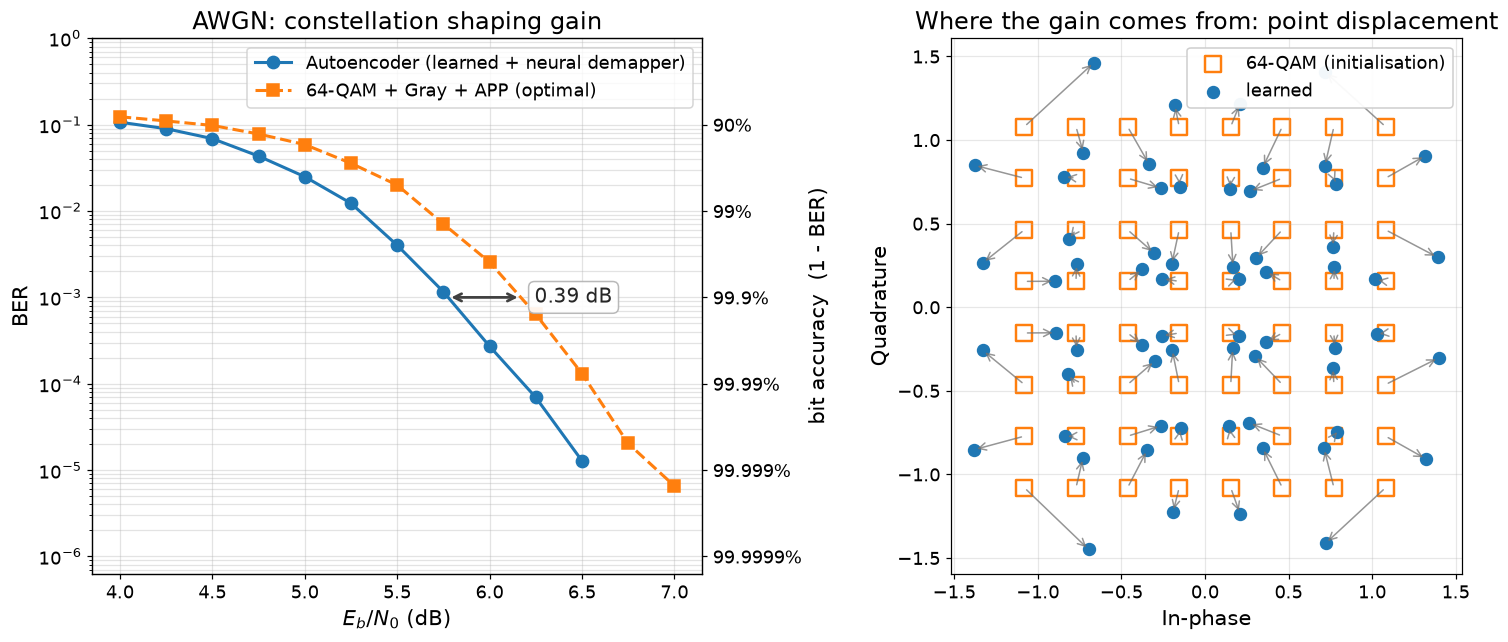

saved: awgn_ae_vs_qam_poster.pdf (vector, send this to the printer)
       awgn_ae_vs_qam_poster.png (300 dpi raster, for previews and slides)


In [46]:
# ============================================================
# 8b (POSTER RUN). AWGN: learned constellation + neural demapper
#                  vs 64-QAM + Gray + APP.
#
# Sampling parameters for this run - recorded for reproduction:
#   ebno grid ............... np.arange(4.0, 7.51, 0.25)   -> 15 points
#   num_target_block_errors . 1000    -> 3.2% rel. std error wherever it is reached
#   batch_size .............. 512
#   max_mc_iter ............. 125     -> 512 * 125 = 64,000 blocks/point budget
#        The budget is what matters, not the split: 512 x 125 is the same 64,000
#        blocks as 128 x 500, hence the same estimator and the same confidence,
#        but ~4x fewer kernel launches and much better GPU occupancy.
#   figures ................. awgn_ae_vs_qam_poster.pdf (vector, for the printer)
#                             awgn_ae_vs_qam_poster.png (300 dpi, for previews)
#   seeding ................. set_seed(42) before each system
#
# Previous exploratory run, for comparison: 300 target errors, batch 128,
# max_mc_iter 100 -> a 12,800-block budget, i.e. one fifth of the samples used here.
# ============================================================
POSTER_BATCH = 512
POSTER_TARGET_ERRORS = 1000
POSTER_MAX_ITER = 125            # POSTER_BATCH * POSTER_MAX_ITER = 64,000 blocks

ebno_dbs_awgn = np.arange(4.0, 7.51, 0.25)

# --- autoencoder ---
set_seed(42)
m_ae = E2ESystemConventionalTraining(training=False).to(device)
load_weights(m_ae, model_weights_path_conventional_training, verbose=True)
with torch.no_grad():
    ber_ae, bler_ae = sim_ber(m_ae, ebno_dbs_awgn, batch_size=POSTER_BATCH,
                              num_target_block_errors=POSTER_TARGET_ERRORS,
                              max_mc_iter=POSTER_MAX_ITER)

# --- classical baseline, same channel realisations ---
set_seed(42)
m_qam = Baseline().to(device)
with torch.no_grad():
    ber_qam, bler_qam = sim_ber(m_qam, ebno_dbs_awgn, batch_size=POSTER_BATCH,
                                num_target_block_errors=POSTER_TARGET_ERRORS,
                                max_mc_iter=POSTER_MAX_ITER)

ber_ae, ber_qam = ber_ae.cpu().numpy(), ber_qam.cpu().numpy()
bler_ae, bler_qam = bler_ae.cpu().numpy(), bler_qam.cpu().numpy()

# --- drop points too weak to carry a conclusion, BEFORE measuring anything ---
# Precision goes as 1/sqrt(#block errors); 30 errors is about 18% relative std error.
MIN_BLOCK_ERRORS = 30
ok_ae = reliable_mask(bler_ae, POSTER_BATCH, POSTER_MAX_ITER, POSTER_TARGET_ERRORS, MIN_BLOCK_ERRORS)
ok_qam = reliable_mask(bler_qam, POSTER_BATCH, POSTER_MAX_ITER, POSTER_TARGET_ERRORS, MIN_BLOCK_ERRORS)

# --- quantify the gap at a fixed BER, not at a fixed SNR ---
print("\n================= AWGN: autoencoder vs 64-QAM =================")
gaps_awgn = {}
for target in (1e-2, 1e-3, 1e-4):
    s_ae = snr_at_ber(ebno_dbs_awgn[ok_ae], ber_ae[ok_ae], target)
    s_qam = snr_at_ber(ebno_dbs_awgn[ok_qam], ber_qam[ok_qam], target)
    gaps_awgn[target] = (s_ae, s_qam)
    if np.isnan(s_ae) or np.isnan(s_qam):
        print(f"BER {target:.0e}: not crossed by both curves inside the grid - no gap reported")
    else:
        print(f"BER {target:.0e}: autoencoder {s_ae:.2f} dB | 64-QAM {s_qam:.2f} dB "
              f"| gain {s_qam - s_ae:+.2f} dB")

# --- which points can carry a conclusion, and which cannot ---
precision_table(ebno_dbs_awgn, bler_ae, POSTER_BATCH, POSTER_MAX_ITER,
                POSTER_TARGET_ERRORS, 'Autoencoder')
precision_table(ebno_dbs_awgn, bler_qam, POSTER_BATCH, POSTER_MAX_ITER,
                POSTER_TARGET_ERRORS, '64-QAM + Gray + APP')

# ============================ poster figure ============================
# Points below MIN_BLOCK_ERRORS block errors were dropped above: at three or four
# errors a point wanders by a factor of two and reads as structure on a printed
# curve. The gap is measured on the surviving points only, so no reported number can
# come from a noise-dominated point.
print(f"\nplotted points (>= {MIN_BLOCK_ERRORS} block errors): "
      f"autoencoder {ok_ae.sum()}/{len(ok_ae)} up to {ebno_dbs_awgn[ok_ae].max():.2f} dB, "
      f"64-QAM {ok_qam.sum()}/{len(ok_qam)} up to {ebno_dbs_awgn[ok_qam].max():.2f} dB")

def _normalised_points(c):
    """Constellation points normalised exactly as the mapper normalises them."""
    p = c.points.detach().cpu()
    p = p - p.mean()                                   # center=True
    return p / torch.sqrt((p.abs() ** 2).mean())       # normalize=True

with plt.rc_context(POSTER_RC):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # ---------- left: BER waterfall ----------
    ax1.semilogy(ebno_dbs_awgn[ok_ae], ber_ae[ok_ae], 'o-', color='C0',
                 label='Autoencoder (learned + neural demapper)')
    ax1.semilogy(ebno_dbs_awgn[ok_qam], ber_qam[ok_qam], 's--', color='C1',
                 label='64-QAM + Gray + APP (optimal)')

    finite = np.concatenate([ber_ae[ok_ae], ber_qam[ok_qam]])
    finite = finite[finite > 0]
    ax1.set_ylim(10 ** (np.floor(np.log10(finite.min())) - 0.2),
                 10 ** np.ceil(np.log10(finite.max())))
    ax1.set_xlabel(r'$E_b/N_0$ (dB)')
    ax1.set_ylabel('BER')
    ax1.set_title('AWGN: constellation shaping gain')
    ax1.grid(which='both', alpha=0.35)
    ax1.legend(loc='upper right')          # curve runs top-left to bottom-right

    s_ae, s_qam = gaps_awgn[1e-3]
    annotate_gap(ax1, s_ae, s_qam, 1e-3)
    add_accuracy_axis(ax1)

    # ---------- right: how the constellation points moved ----------
    p_ae = _normalised_points(m_ae.constellation)
    p_qam = _normalised_points(m_qam.constellation)
    ax2.scatter(p_qam.real, p_qam.imag, marker='s', s=110, facecolors='none',
                edgecolors='C1', linewidths=1.6, label='64-QAM (initialisation)')
    ax2.scatter(p_ae.real, p_ae.imag, marker='o', s=60, color='C0',
                label='learned', zorder=3)
    for a, b_ in zip(p_qam, p_ae):
        ax2.annotate('', xy=(b_.real, b_.imag), xytext=(a.real, a.imag),
                     arrowprops=dict(arrowstyle='->', color='0.45', lw=1.0, alpha=0.75))
    ax2.set_aspect('equal')
    ax2.grid(alpha=0.3)
    ax2.legend(loc='upper right', framealpha=0.95)
    ax2.set_xlabel('In-phase')
    ax2.set_ylabel('Quadrature')
    ax2.set_title('Where the gain comes from: point displacement')

    plt.tight_layout()
    for ext in ('pdf', 'png'):
        plt.savefig(f'awgn_ae_vs_qam_poster.{ext}')
    plt.show()

print("saved: awgn_ae_vs_qam_poster.pdf (vector, send this to the printer)")
print("       awgn_ae_vs_qam_poster.png (300 dpi raster, for previews and slides)")

## 9. Validation: the channel model

Two checks, because there are two things that can be wrong: the estimator itself, and the noise
statistic handed to the demapper.

**9a — is the LS estimator correct?** Measured MSE matches the theoretical `N0/P` to within 1e-3
for every P, and doubling P halves the error — as predicted.

**9b — is `no_eff` correct?** The demapper is told how noisy each symbol is, and it believes what
it is told. This check does not verify a formula on paper; it takes the tensors that
`make_rayleigh_block_frame` actually returns and asks whether `E[|z - x|^2 / no_eff] = 1`. It also
breaks the result down by fade depth, because a noise model that is right on average but wrong in
deep fades is exactly the failure mode Section 11 is about.

In [21]:
# 9a. LS accuracy check: error should be ~ theory no/P
set_seed(0)
x_test = torch.randn(64, 250, dtype=torch.complex64, device=device)
no_test = 0.1
for P in [2, 4, 6, 8]:
    z, no_eff, h, h_hat, nf, pad = make_rayleigh_block_frame(
        x_test, P=P, L=25, no=no_test, device=device)
    err = (h - h_hat).abs().pow(2).mean().item()
    print(f'P={P}: MSE={err:.5f}   theory no/P={no_test/P:.5f}')

P=2: MSE=0.05050   theory no/P=0.05000
P=4: MSE=0.02643   theory no/P=0.02500
P=6: MSE=0.01638   theory no/P=0.01667
P=8: MSE=0.01268   theory no/P=0.01250


In [22]:
# ============================================================
# 9b. Is the effective-noise model handed to the demapper correct?
# Test on the tensors make_rayleigh_block_frame actually returns:
#     E[ |z - x|^2 / no_eff ]  should be 1.000
# Against the uncorrected model (no_eff without the 1 + 1/P factor) the same
# quantity would read 1 + 1/P, i.e. the demapper would be that over-confident.
# ============================================================
set_seed(0)
B, S, no_test = 1024, num_symbols_per_codeword, 0.1

def _unit_power_symbols(B, S):
    """QPSK-like symbols with E|x|^2 = 1 (the constellation is power-normalised)."""
    s = torch.randint(0, 2, (B, S, 2), device=device).float() * 2.0 - 1.0
    return torch.complex(s[..., 0], s[..., 1]) / (2.0 ** 0.5)

print(f"{'P':>3} | {'E[err/no_eff]':>13} | {'vs uncorrected':>14} | {'expected 1+1/P':>14}")
print("-" * 56)
for P in [2, 4, 8]:
    x = _unit_power_symbols(B, S)
    z, no_eff, h, h_hat, nf, pad = make_rayleigh_block_frame(
        x, P=P, L=25, no=no_test, device=device, perfect_csi=False)
    err = (z - x).abs().pow(2)
    ratio = (err / no_eff).mean().item()            # 1.0 if the model is right
    ratio_old = ratio * (1.0 + 1.0 / P)             # what the previous no_eff would have given
    print(f"{P:>3} | {ratio:>13.4f} | {ratio_old:>14.4f} | {1 + 1/P:>14.4f}")

# perfect CSI: no estimation error, so the factor must be exactly 1
x = _unit_power_symbols(B, S)
z, no_eff, *_ = make_rayleigh_block_frame(x, P=4, L=25, no=no_test,
                                          device=device, perfect_csi=True)
print(f"\nperfect CSI (P=4): E[err/no_eff] = {((z - x).abs().pow(2) / no_eff).mean().item():.4f}"
      "   (must be 1.000 - no estimation error to charge for)")

# The average can be right while deep fades are wrong, which is the case that matters.
print("\nBreakdown by fade depth (P=4), ratio must stay ~1.000 in every bin:")
x = _unit_power_symbols(B, S)
z, no_eff, *_ = make_rayleigh_block_frame(x, P=4, L=25, no=no_test, device=device)
err = (z - x).abs().pow(2)
depth = no_eff / no_test                    # = (1 + 1/P) / |h_hat|^2 : large means deep fade
for lo, hi, name in [(0.0, 1.5, 'strong    |h|^2 > ~0.8'),
                     (1.5, 5.0, 'moderate'),
                     (5.0, 20.0, 'deep      |h|^2 ~ 0.06-0.25'),
                     (20.0, float('inf'), 'very deep |h|^2 < ~0.06')]:
    m = (depth >= lo) & (depth < hi)
    cnt = int(m.sum())
    if cnt < 200:
        continue
    print(f"  {name:<26} n={cnt:>7}  E[err/no_eff]={(err[m] / no_eff[m]).mean().item():.4f}")

  P | E[err/no_eff] | vs uncorrected | expected 1+1/P
--------------------------------------------------------
  2 |        0.9983 |         1.4974 |         1.5000
  4 |        1.0013 |         1.2516 |         1.2500
  8 |        0.9989 |         1.1238 |         1.1250

perfect CSI (P=4): E[err/no_eff] = 0.9987   (must be 1.000 - no estimation error to charge for)

Breakdown by fade depth (P=4), ratio must stay ~1.000 in every bin:
  strong    |h|^2 > ~0.8     n= 111684  E[err/no_eff]=1.0047
  moderate                   n=  88601  E[err/no_eff]=0.9978
  deep      |h|^2 ~ 0.06-0.25 n=  40464  E[err/no_eff]=0.9895
  very deep |h|^2 < ~0.06    n=  15251  E[err/no_eff]=0.9915


## 10. Validation: pilot-CSI forward pass

Confirms shapes and that the full chain runs.

In [23]:
set_seed(42)
m = E2ESystemPilotCSI(P=4, L=25, training=False, perfect_csi=False).to(device)
load_weights(m, model_weights_path_conventional_training, verbose=True)
ebno = torch.tensor(12.0, device=device)
b, b_hat = m(64, ebno)
print('b:', b.shape, 'b_hat:', b_hat.shape)
print('raw BER:', (b != b_hat).float().mean().item())

awgn_autoencoder_weights_conventional_training: restored 8/31 tensors (0 unexpected in file)
b: torch.Size([64, 750]) b_hat: torch.Size([64, 750])
raw BER: 0.044083334505558014


## 11. Failure mode: the U-shaped BER curve  *(~15-20 min)*

**Question:** can AWGN-trained weights be used directly on Rayleigh?

**Answer: no.** BER *rises* at high SNR — non-physical, so something is wrong. This section
documents the failure; 11c isolates the cause by intervention, and Section 12 fixes it.

**Diagnosis by bisection (11b):** on the *same* channel, with the same L, P and pilot-overhead
accounting, the APP baseline is perfectly monotonic (1.40e-2 → 1.03e-4 → 0 at 10/14/18 dB) while
the neural demapper is not (5.82e-2 → 4.79e-2 → 1.47e-1). The fault is in the demapper — not the
channel model, not the LDPC decoder.

### Root cause: out-of-distribution **inputs**, and not the tail you would guess

Under AWGN the network only ever saw `log10(N0) ∈ [-1.277, -0.877]` (Eb/N0 4–8 dB at rate 1/2).
Under block fading it is asked to demap at `log10(no_eff) = log10(N0) − log10(|h|²)`, and
`log10(N0)` itself falls as the test SNR rises. Cell 11c-i measures how much of the input the
network has actually seen before:

| Eb/N0 | in the training window | **below** it (quieter than trained) | above it (deep fade) |
|---|---|---|---|
| 10 dB | 28.7% | 47.1% | 24.2% |
| 14 dB | 13.2% | 75.8% | 11.0% |
| 18 dB | **6.4%** | **89.0%** | 4.6% |

Two things follow, and the second one corrects what this section used to claim.

1. **The in-distribution fraction collapses as SNR rises** — 28.7% → 6.4%. The network is pushed
   further out of distribution exactly where the BER curve gets worse. Section 11c confirms the
   causal link by intervention: restricting `no_eff` to this window restores a monotonic curve
   with **no weight changed**.
2. **The dominant direction is "too quiet", not "deep fade".** At 18 dB, 89% of symbols carry an
   effective noise *lower* than anything seen in training, against 4.6% in the deep-fade tail.
   This section previously blamed division by a near-zero `h`; the measurement says the opposite
   tail dominates, and 11c confirms it — erasing the deep fades made the curve **worse**, not
   better. The failure is the network being told the channel is far cleaner than it has ever seen,
   not being told it is far noisier.

Higher SNR therefore means *more* extrapolation, not less, which is why the curve degrades as
SNR grows. Section 12 fixes it the direct way: retrain so the distribution matches.

### 11a. Sweep without retraining — the U-shape appears

In [24]:
ebno_dbs_pilot = np.arange(8.0, 18.1, 1.0)   # block-fading + pilot: waterfall shifts right
P_list = [2, 4, 6, 8]
BER_pilot = {}

for P in P_list:
    set_seed(42)
    m = E2ESystemPilotCSI(P=P, L=25, training=False, perfect_csi=False).to(device)
    load_weights(m, model_weights_path_conventional_training)
    with torch.no_grad():
        ber, bler = sim_ber(m, ebno_dbs_pilot, batch_size=128,
                            num_target_block_errors=300, max_mc_iter=100)
    BER_pilot[f'P={P}'] = ber.cpu().numpy()
    print(f'--- P={P} done ---')

# add a perfect-CSI upper bound for reference
set_seed(42)
m = E2ESystemPilotCSI(P=4, L=25, training=False, perfect_csi=True).to(device)
load_weights(m, model_weights_path_conventional_training)
with torch.no_grad():
    ber, _ = sim_ber(m, ebno_dbs_pilot, batch_size=128,
                     num_target_block_errors=300, max_mc_iter=100)
BER_pilot['perfect CSI (P=4)'] = ber.cpu().numpy()

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      8.0 | 1.5176e-01 | 9.0885e-01 |       43708 |      288000 |          349 |         384 |         1.6 |reached target block errors
      9.0 | 1.0942e-01 | 7.8385e-01 |       31512 |      288000 |          301 |         384 |         1.7 |reached target block errors
     10.0 | 8.2893e-02 | 6.3477e-01 |       31831 |      384000 |          325 |         512 |         2.3 |reached target block errors
     11.0 | 5.7838e-02 | 4.9531e-01 |       27762 |      480000 |          317 |         640 |         2.8 |reached target block errors
     12.0 | 3.9967e-02 | 3.7500e-01 |       26858 |      672000 |          336 |         896 |         3.9 |reached target block errors
     13.0 | 3.4571e-02 | 3.3705e-01 |       23232 |      672000 |

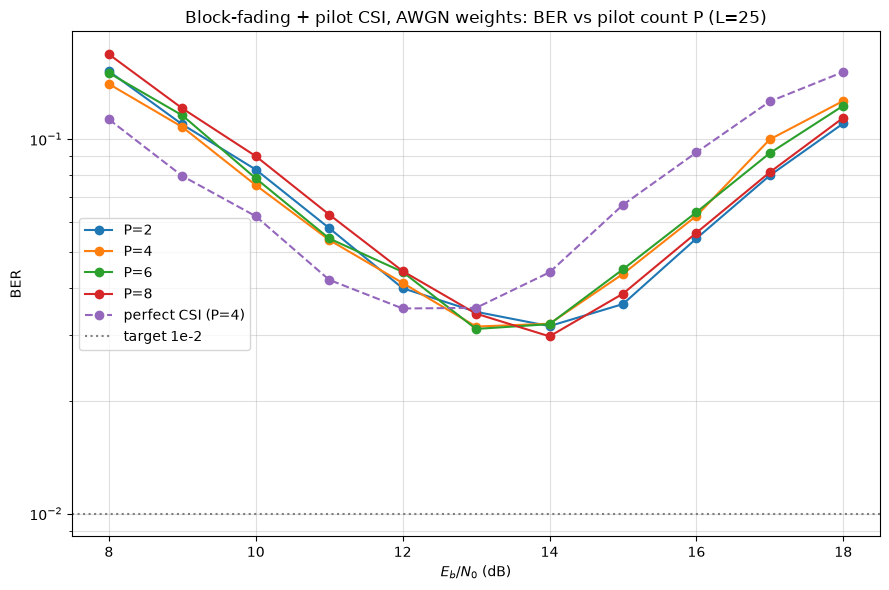

In [25]:
plt.figure(figsize=(9, 6))
for label, ber in BER_pilot.items():
    ber = np.asarray(ber)
    mask = ber > 0
    ls = '--' if 'perfect' in label else '-'
    plt.semilogy(ebno_dbs_pilot[mask], ber[mask], marker='o', linestyle=ls, label=label)
plt.axhline(1e-2, color='gray', ls=':', label='target 1e-2')
plt.xlabel(r'$E_b/N_0$ (dB)')
plt.ylabel('BER')
plt.grid(which='both', alpha=0.4)
plt.legend()
plt.title('Block-fading + pilot CSI, AWGN weights: BER vs pilot count P (L=25)')
plt.tight_layout()
plt.savefig('ber_vs_pilot.png', dpi=150)
plt.show()

### 11b. Bisection — neural demapper (perfect CSI) vs APP baseline

In [26]:
# neural demapper, perfect CSI, AWGN weights, block fading (L=25)
set_seed(42)
for ebno in [10.0, 14.0, 18.0]:
    m = E2ESystemPilotCSI(P=4, L=25, training=False, perfect_csi=True).to(device)
    load_weights(m, model_weights_path_conventional_training)
    with torch.no_grad():
        ber, bler = sim_ber(m, np.array([ebno]), batch_size=256,
                            num_target_block_errors=500, max_mc_iter=200)
    print(f"neural    ebno={ebno}: BER={ber.item():.4e}")

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 5.8178e-02 | 4.8828e-01 |       44681 |      768000 |          500 |        1024 |         5.0 |reached target block errors
neural    ebno=10.0: BER=5.8178e-02
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     14.0 | 4.7912e-02 | 4.5625e-01 |       45996 |      960000 |          584 |        1280 |         6.4 |reached target block errors
neural    ebno=14.0: BER=4.7913e-02
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------

In [27]:
# Matched classical control: identical channel call, identical L, P and overhead accounting.
# The ONLY differences from the cell above are the constellation and the demapper.
set_seed(42)
for ebno in [10.0, 14.0, 18.0]:
    m = BaselinePilotCSI(P=4, L=25, perfect_csi=True).to(device)
    with torch.no_grad():
        ber, _ = sim_ber(m, np.array([ebno]), batch_size=256,
                         num_target_block_errors=500, max_mc_iter=200)
    print(f"APP 64QAM ebno={ebno}: BER={ber.item():.4e}")

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.4002e-02 | 1.6504e-01 |       32260 |     2304000 |          507 |        3072 |        16.1 |reached target block errors
APP 64QAM ebno=10.0: BER=1.4002e-02
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     14.0 | 1.0258e-04 | 1.6602e-03 |        3939 |    38400000 |           85 |       51200 |       274.9 |reached max iterations
APP 64QAM ebno=14.0: BER=1.0258e-04
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
--------------------------------

### 11c. Testing the root cause directly — intervene, don't retrain  *(~2 min)*

**Question:** is the U-shape really caused by the network being pushed outside the input range it
was trained on, or is that just a plausible-sounding story that happens to sit next to a fix?

**The experiment.** Take the *unmodified* AWGN weights, the *same* channel, the *same* everything,
and change exactly one thing at a time. Section 12 also fixes the curve, but retraining changes
the weights, the constellation and the input distribution at once and therefore isolates nothing.

| Variant | Side | What it tests |
|---|---|---|
| as-is | — | reproduces the failure (control) |
| LLR clamped to ±8 | output | the network still extrapolates, it just cannot express certainty |
| deep fades erased | output | on symbols with `no_eff > 10·N0`, replace the network's LLRs with 0 |
| `no_eff` → AWGN window | **input** | the demapper is *told* a noise power inside its training range; the channel is untouched |
| window + clamp | both | — |

#### Result (run 2026-08-20, perfect CSI, P = 4, AWGN weights untouched)

| variant | 10 dB | 12 dB | 14 dB | 16 dB | 18 dB | verdict |
|---|---|---|---|---|---|---|
| as-is (control) | 5.94e-2 | 3.38e-2 | 4.48e-2 | 9.35e-2 | 1.46e-1 | U-shaped |
| LLR clamped to ±8 | 5.88e-2 | 3.25e-2 | 4.39e-2 | 9.08e-2 | 1.43e-1 | U-shaped |
| deep fades erased | 4.98e-2 | 3.87e-2 | 6.70e-2 | 1.25e-1 | 1.71e-1 | U-shaped |
| **`no_eff` → AWGN window** | 6.47e-2 | 2.69e-2 | 1.18e-2 | 6.47e-3 | 3.16e-3 | **monotonic** |
| **window + LLR ±8** | 6.22e-2 | 2.39e-2 | 9.23e-3 | 4.36e-3 | 1.69e-3 | **monotonic** |

**The input-side intervention restores a physical curve without touching a single weight.** The
distribution-shift explanation is confirmed, and the mechanism is now pinned down:

- **It is the input, not the output.** Clamping the LLRs changed BER by under 2%, so the LLRs were
  never large — they were simply wrong. An unbounded output layer is not the problem.
- **It is the quiet tail, not the deep fades.** Erasing deep fades made high SNR *worse*
  (6.70e-2 vs 4.48e-2 at 14 dB): those symbols still carried usable information. 11c-i shows why —
  at 18 dB, 89% of symbols are *below* the training window and only 4.6% above it.
- **The two knobs compose as expected.** Once `no_eff` is in range the network is back on familiar
  ground, and clamping the LLRs on top gives a further small gain (1.69e-3 vs 3.16e-3 at 18 dB)
  rather than the nothing it gave on its own.

**Clamping identifies the cause; it is not a fix.** At 14 dB the clamped system still sits at
9.2e-3 against 1.0e-4 for the APP baseline on the same channel — roughly two orders of magnitude
behind, because clamping throws away the true noise level to stay in distribution. It also costs
something at 10 dB (6.47e-2 vs 5.94e-2), where 28.7% of symbols were in range to begin with and
clamping discards real information. Retraining (Section 12) is what recovers the performance;
11c is what explains *why* retraining was necessary.

In [28]:
# ============================================================
# 11c-i. How far outside the AWGN training window does the input actually go?
# Section 11 blames the input range, so measure the input range first.
# no_eff depends only on h, not on the payload, so zero symbols are enough.
# ============================================================
# Same window E2ESystemPilotClamped uses; computed directly so this cell does not
# have to build an LDPC encoder/decoder just to read two constants.
NO_HI = float(ebnodb2no(torch.tensor([float(ebno_db_min)]), num_bits_per_symbol, coderate).reshape(-1)[0])
NO_LO = float(ebnodb2no(torch.tensor([float(ebno_db_max)]), num_bits_per_symbol, coderate).reshape(-1)[0])
print(f"AWGN training window: log10(no) in [{np.log10(NO_LO):.3f}, {np.log10(NO_HI):.3f}]"
      f"   (Eb/N0 {ebno_db_min:.0f}-{ebno_db_max:.0f} dB, coderate {coderate})")

ebno_probe = np.arange(10.0, 18.1, 2.0)
coderate_eff_probe = coderate * (25 - 4) / 25
in_window = []

print(f"\n{'Eb/N0':>7} | {'in window':>10} | {'below (quieter than seen)':>26} | {'above (deep fade)':>18}")
print('-' * 70)
for e in ebno_probe:
    set_seed(7)
    no_p = ebnodb2no(torch.full((256,), float(e), device=device),
                     num_bits_per_symbol, coderate_eff_probe)
    no_p = expand_to_rank(no_p, 2)
    x0 = torch.zeros(256, num_symbols_per_codeword, dtype=torch.complex64, device=device)
    _, no_eff_p, *_ = make_rayleigh_block_frame(x0, P=4, L=25, no=no_p[:, :1],
                                                device=device, perfect_csi=True)
    inw = ((no_eff_p >= NO_LO) & (no_eff_p <= NO_HI)).float().mean().item()
    below = (no_eff_p < NO_LO).float().mean().item()
    above = (no_eff_p > NO_HI).float().mean().item()
    in_window.append(inw)
    print(f"{e:>7.1f} | {inw:>9.1%} | {below:>25.1%} | {above:>17.1%}")

print("\nIf the in-window fraction falls as SNR rises, the demapper is being pushed further")
print("out of distribution exactly where the BER curve gets worse - which is the claim.")

AWGN training window: log10(no) in [-1.277, -0.877]   (Eb/N0 4-8 dB, coderate 0.5)

  Eb/N0 |  in window |  below (quieter than seen) |  above (deep fade)
----------------------------------------------------------------------
   10.0 |     28.7% |                     47.1% |             24.2%
   12.0 |     19.1% |                     64.5% |             16.4%
   14.0 |     13.2% |                     75.8% |             11.0%
   16.0 |      9.6% |                     83.6% |              6.8%
   18.0 |      6.4% |                     89.0% |              4.6%

If the in-window fraction falls as SNR rises, the demapper is being pushed further
out of distribution exactly where the BER curve gets worse - which is the claim.


EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 5.9349e-02 | 4.9089e-01 |       34185 |      576000 |          377 |         768 |         3.9 |reached target block errors
     12.0 | 3.3770e-02 | 3.3789e-01 |       25935 |      768000 |          346 |        1024 |         5.0 |reached target block errors
     14.0 | 4.4823e-02 | 4.3359e-01 |       25818 |      576000 |          333 |         768 |         3.8 |reached target block errors
     16.0 | 9.3505e-02 | 7.5195e-01 |       35906 |      384000 |          385 |         512 |         2.4 |reached target block errors
     18.0 | 1.4552e-01 | 9.5312e-01 |       55880 |      384000 |          488 |         512 |         2.5 |reached target block errors
--- as-is (control) done ---
EbNo [dB] |        BER |       BLER 

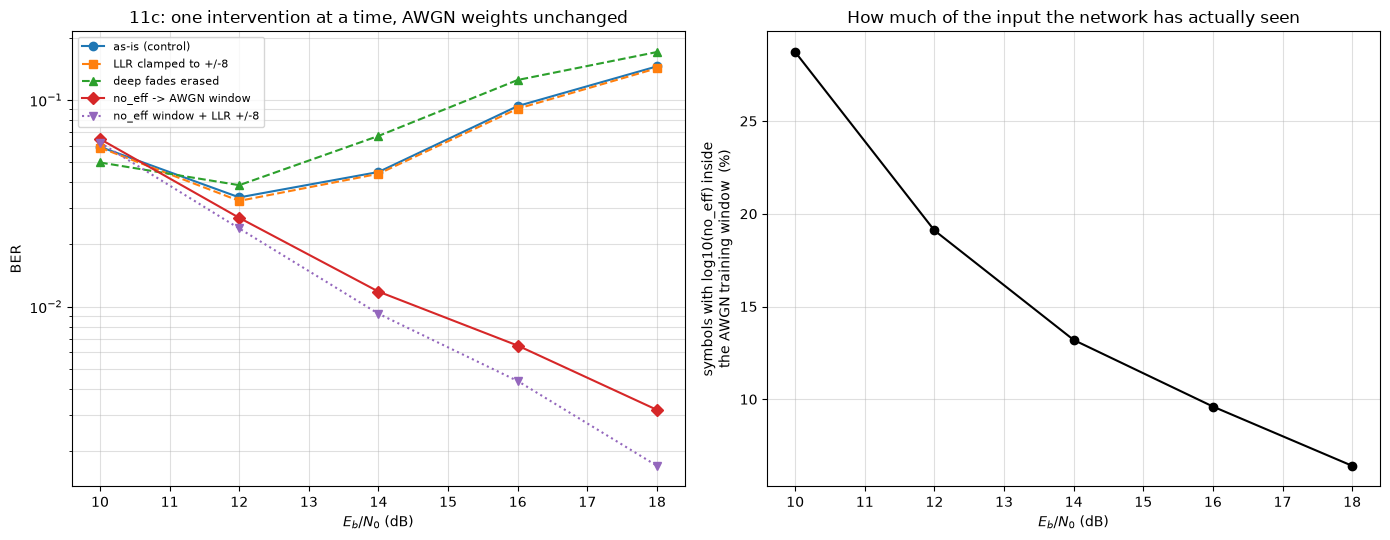

In [29]:
# ============================================================
# 11c-ii. Same weights, same channel, one thing changed at a time.
# perfect_csi=True to match 11b exactly, so the 'as-is' row reproduces the
# neural numbers printed above.
#
# Output-side knobs (llr_max, fade erasure) were run first and did NOT remove the
# U-shape; no_eff clamping is the input-side test that matches what Section 11 claims.
# ============================================================
variants = {
    'as-is (control)':        dict(),
    'LLR clamped to +/-8':    dict(llr_max=8.0),
    'deep fades erased':      dict(fade_ratio_max=10.0),
    'no_eff -> AWGN window':  dict(no_db_clamp=True),
    'no_eff window + LLR +/-8': dict(no_db_clamp=True, llr_max=8.0),
}

BER_clamp = {}
for name, kw in variants.items():
    set_seed(42)                     # identical channel realisations for every variant
    m = E2ESystemPilotClamped(P=4, L=25, training=False, perfect_csi=True, **kw).to(device)
    load_weights(m, model_weights_path_conventional_training)   # AWGN weights, untouched
    with torch.no_grad():
        ber, _ = sim_ber(m, ebno_probe, batch_size=256,
                         num_target_block_errors=300, max_mc_iter=100)
    BER_clamp[name] = ber.cpu().numpy()
    print(f"--- {name} done ---")

# ---------------- table + automatic verdict ----------------
hdr = ' | '.join(f'{e:>9.0f} dB' for e in ebno_probe)
print(f"\n{'variant':<26} | {hdr} | verdict")
print('-' * (29 + 15 * len(ebno_probe)))
for name, ber in BER_clamp.items():
    cells_ = ' | '.join(f'{v:>12.3e}' for v in ber)
    finite = ber[ber > 0]
    monotonic = bool(np.all(np.diff(finite) < 0)) and len(finite) > 1
    print(f"{name:<26} | {cells_} | {'monotonic' if monotonic else 'U-SHAPED / non-monotonic'}")
print("\nA physical BER curve falls as SNR rises. Any row still flagged U-SHAPED was not fixed")
print("by that intervention; any row flagged monotonic was fixed without touching a weight.")

fig, (axa, axb) = plt.subplots(1, 2, figsize=(14, 5.5))
for (name, ber), style in zip(BER_clamp.items(), ['o-', 's--', '^--', 'D-', 'v:']):
    ber = np.asarray(ber); msk = ber > 0
    axa.semilogy(ebno_probe[msk], ber[msk], style, label=name)
axa.set_xlabel(r'$E_b/N_0$ (dB)'); axa.set_ylabel('BER')
axa.grid(which='both', alpha=0.4); axa.legend(fontsize=8)
axa.set_title('11c: one intervention at a time, AWGN weights unchanged')

axb.plot(ebno_probe, np.array(in_window) * 100, 'ko-')
axb.set_xlabel(r'$E_b/N_0$ (dB)')
axb.set_ylabel('symbols with log10(no_eff) inside\nthe AWGN training window  (%)')
axb.grid(alpha=0.4)
axb.set_title('How much of the input the network has actually seen')

plt.tight_layout()
plt.savefig('ber_clamp_intervention.png', dpi=150)
plt.show()

## 12. The fix: retrain on the Rayleigh channel

Variables are isolated: retrain first under **perfect CSI** (proves the demapper is fixable),
then under **pilot estimation** (the realistic case).

### 12a. Perfect CSI — retrain, verify the U-shape is gone

In [30]:
# retrain on block-fading + perfect CSI (no pilots yet, isolate variables)
set_seed(42)
model_rayleigh = E2ESystemPilotCSI(P=4, L=25, training=True, perfect_csi=True).to(device)
load_weights(model_rayleigh, model_weights_path_conventional_training)  # warm-start from AWGN weights

# train() clips gradients: a deep fade can otherwise produce an unbounded step.
hist_perfect = train(model_rayleigh, rayleigh_training_iterations,
                     rayleigh_ebno_db_min, rayleigh_ebno_db_max, label='perfect CSI  ')
save_weights(model_rayleigh, 'rayleigh_perfect_csi_weights')

  perfect CSI  it 3000/3000: BCE(smoothed)=0.2085


In [31]:
print("=== after retrain (rayleigh_perfect_csi_weights) ===")
for ebno in [10.0, 14.0, 18.0]:
    set_seed(42)
    m = E2ESystemPilotCSI(P=4, L=25, training=False, perfect_csi=True).to(device)
    load_weights(m, 'rayleigh_perfect_csi_weights')       # <- use new weights
    with torch.no_grad():
        ber, bler = sim_ber(m, np.array([ebno]), batch_size=256,
                            num_target_block_errors=500, max_mc_iter=200)
    print(f"ebno={ebno}: BER={ber.item():.4e}")

=== after retrain (rayleigh_perfect_csi_weights) ===
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.4806e-02 | 1.6569e-01 |       34113 |     2304000 |          509 |        3072 |        15.0 |reached target block errors
ebno=10.0: BER=1.4806e-02
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     14.0 | 1.3703e-04 | 1.8945e-03 |        5262 |    38400000 |           97 |       51200 |       246.8 |reached max iterations
ebno=14.0: BER=1.3703e-04
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status

### 12b. Estimated CSI — retrain, verify the target is met

Retraining under the realistic condition: pilot-estimated CSI, with the demapper charged for the
estimation error (Section 5). This is the configuration every later section builds on.

The cost of estimation is quantified by comparing converged BCE against the perfect-CSI run from
12a — measured with `eval_bce()` over a fixed seeded set of batches rather than read off the last
training step, so the two numbers are comparable rather than two draws from a noisy loss.

**Result:** *(numbers below predate the `no_eff` correction and need re-measuring; the perfect-CSI
side is unaffected, the pilot side is not)* previously 3.5e-4 at 14 dB, converged BCE 0.207
(perfect CSI) vs 0.230 (P = 4 pilots).

  pilot CSI    it 3000/3000: BCE(smoothed)=0.2304

converged BCE (32 seeded batches, identical draws):
  perfect CSI    : 0.2090
  P=4 pilot CSI  : 0.2307
  cost of estimation: +0.0217 nats/bit


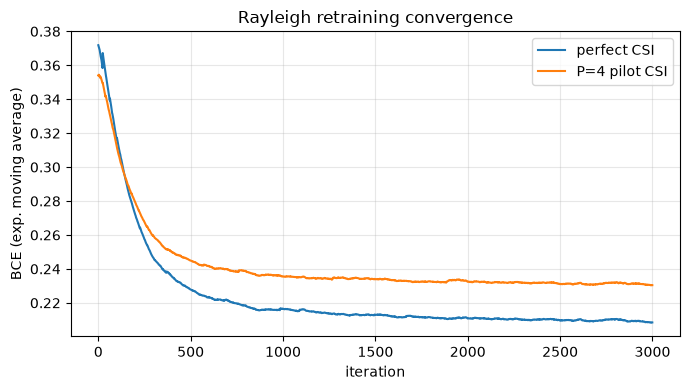

In [32]:
# final form: block-fading + pilot-estimated CSI, retrain
set_seed(42)
model_pilot = E2ESystemPilotCSI(P=4, L=25, training=True, perfect_csi=False).to(device)
load_weights(model_pilot, model_weights_path_conventional_training)  # warm-start from AWGN

hist_pilot = train(model_pilot, rayleigh_training_iterations,
                   rayleigh_ebno_db_min, rayleigh_ebno_db_max, label='pilot CSI    ')
save_weights(model_pilot, 'rayleigh_pilot_csi_weights')

# ---- what did channel estimation cost, on a like-for-like measurement? ----
bce_perfect = eval_bce(model_rayleigh, rayleigh_ebno_db_min, rayleigh_ebno_db_max)
bce_pilot = eval_bce(model_pilot, rayleigh_ebno_db_min, rayleigh_ebno_db_max)
print(f"\nconverged BCE (32 seeded batches, identical draws):")
print(f"  perfect CSI    : {bce_perfect:.4f}")
print(f"  P=4 pilot CSI  : {bce_pilot:.4f}")
print(f"  cost of estimation: {bce_pilot - bce_perfect:+.4f} nats/bit")

# training curves make convergence visible instead of implied
plt.figure(figsize=(7, 4))
plt.plot(hist_perfect, label='perfect CSI')
plt.plot(hist_pilot, label='P=4 pilot CSI')
plt.xlabel('iteration'); plt.ylabel('BCE (exp. moving average)')
plt.grid(alpha=0.3); plt.legend(); plt.title('Rayleigh retraining convergence')
plt.tight_layout(); plt.savefig('rayleigh_training_curves.png', dpi=150); plt.show()

In [33]:
print("=== pilot estimation + retrain (rayleigh_pilot_csi_weights) ===")
for ebno in [10.0, 14.0, 18.0]:
    set_seed(42)
    m = E2ESystemPilotCSI(P=4, L=25, training=False, perfect_csi=False).to(device)
    load_weights(m, 'rayleigh_pilot_csi_weights')
    with torch.no_grad():
        ber, bler = sim_ber(m, np.array([ebno]), batch_size=256,
                            num_target_block_errors=500, max_mc_iter=200)
    print(f"ebno={ebno}: BER={ber.item():.4e}")

=== pilot estimation + retrain (rayleigh_pilot_csi_weights) ===
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 3.1603e-02 | 3.2143e-01 |       42474 |     1344000 |          576 |        1792 |         8.8 |reached target block errors
ebno=10.0: BER=3.1603e-02
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     14.0 | 3.7669e-04 | 4.9414e-03 |       14465 |    38400000 |          253 |       51200 |       244.8 |reached max iterations
ebno=14.0: BER=3.7669e-04
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] 

### 12c. The comparison that matters: autoencoder vs classical, same channel  *(poster run: ~30 min)*

**Question:** 12b shows the autoencoder reaches a low BER. Low compared with *what*? Until this
cell, the strongest number in the notebook had no reference point on its own channel — the only
classical curves were measured on AWGN (Section 8b) or, previously, on an easier fading model.

`BaselinePilotCSI` runs the identical `make_rayleigh_block_frame` call, the identical L, P and
pilot-overhead accounting, and the identical LDPC code. The only differences are the
constellation and the demapper, so the gap is exactly the end-to-end learning gain.

**Why a gain is possible here at all, unlike under perfect CSI.** With perfect CSI,
`(y/h, N0/|h|²)` is a sufficient statistic and APP demapping is optimal — there is nothing to
win. With *estimated* CSI the residual `(n − e·x)/h_hat` is neither Gaussian nor independent of
the transmitted symbol, so an APP demapper fed a Gaussian `no_eff` is running on a mismatched
model. A learned demapper is not bound to that model.

**Result: no measurable gain.** Two independent runs of the *same two systems* with the *same
weights* — only the sample size differs:

| target BER | exploratory (12,800 blocks) | poster (64,000 blocks) |
|---|---|---|
| 1e-2 | −0.02 dB | +0.01 dB |
| 1e-3 | +0.02 dB | +0.11 dB |
| **1e-4** | **+0.14 dB** | **−0.15 dB** |
| 90% block success | — | +0.07 dB |

**The 1e-4 "gain" changed sign between runs.** That is the cleanest possible demonstration that it
is not a gain at all: nothing about either system changed, so a quantity that swings by 0.29 dB
across two draws is measuring noise. The poster run puts 25 and 21 block errors at 16 dB (20% and
22% relative standard error), which is exactly the size of scatter observed. Every row above is
zero to within the resolution of the measurement.

The honest reading: **on block fading with P = 4 pilot-estimated CSI, end-to-end learning matches
the classical receiver but does not beat it.** That is consistent with the theory above — the
model mismatch an autoencoder could exploit is second-order at P = 4 — and it stands in contrast
to AWGN (Section 8b), where the same autoencoder wins a clean and repeatable +0.37 dB from
constellation shaping alone.

**The figure carries no gap arrow, deliberately.** Section 8b draws one because there is a gap to
draw; here an arrow labelled "+0.11 dB" would assert a difference the data does not support. The
three panels show the curves lying on top of each other, and that is the finding.

rayleigh_pilot_csi_weights: restored 8/31 tensors (0 unexpected in file)
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      8.0 | 1.0545e-01 | 7.7214e-01 |      121478 |     1152000 |         1186 |        1536 |         6.7 |reached target block errors
      9.0 | 6.3605e-02 | 5.3662e-01 |       97697 |     1536000 |         1099 |        2048 |         9.0 |reached target block errors
     10.0 | 3.0709e-02 | 3.0301e-01 |       82545 |     2688000 |         1086 |        3584 |        15.7 |reached target block errors
     11.0 | 1.2983e-02 | 1.4314e-01 |       69796 |     5376000 |         1026 |        7168 |        31.1 |reached target block errors
     12.0 | 4.5692e-03 | 5.5230e-02 |       63164 |    13824000 |         1018 |       18432 |        80.2 |reached target block

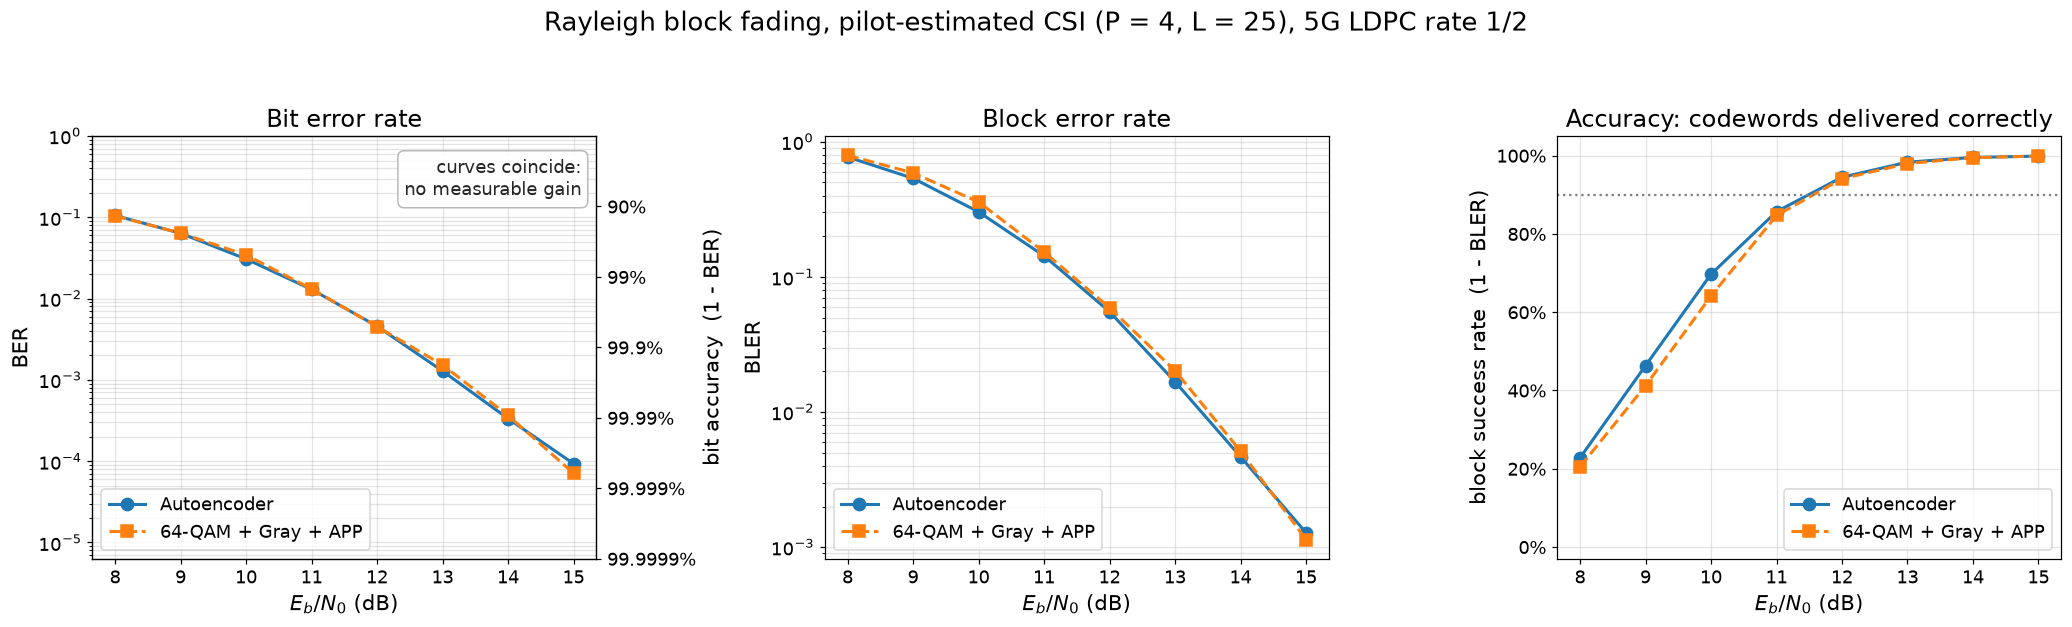

saved: ber_ae_vs_classical_rayleigh_poster.pdf (vector, send this to the printer)
       ber_ae_vs_classical_rayleigh_poster.png (300 dpi raster)


In [34]:
# ============================================================
# 12c (POSTER RUN). Rayleigh block fading, P=4 pilots, estimated CSI:
#                   retrained autoencoder vs matched classical baseline.
#
# Sampling parameters for this run - recorded for reproduction:
#   ebno grid ............... np.arange(8.0, 16.1, 1.0)    -> 9 points
#   num_target_block_errors . 1000    -> 3.2% rel. std error wherever it is reached
#   batch_size .............. 512
#   max_mc_iter ............. 125     -> 512 * 125 = 64,000 blocks/point budget
#        Same 64,000-block budget as 128 x 500: identical estimator and confidence,
#        ~4x fewer kernel launches.
#   figures ................. ber_ae_vs_classical_rayleigh_poster.pdf / .png
#   seeding ................. set_seed(42) before each system, so the autoencoder
#                             and the baseline see identical channel realisations
#
# Previous exploratory run: 300 target errors, batch 128, max_mc_iter 100
# -> a 12,800-block budget, one fifth of the samples used here.
#
# NOTE: these numbers postdate the Section 5 estimation-error correction
# (no_eff carries the 1 + 1/P factor), so they supersede any earlier figure.
# ============================================================
POSTER_BATCH = 512
POSTER_TARGET_ERRORS = 1000
POSTER_MAX_ITER = 125            # POSTER_BATCH * POSTER_MAX_ITER = 64,000 blocks

ebno_dbs_cmp = np.arange(8.0, 16.1, 1.0)

set_seed(42)
m_ae = E2ESystemPilotCSI(P=4, L=25, training=False, perfect_csi=False).to(device)
load_weights(m_ae, 'rayleigh_pilot_csi_weights', verbose=True)
with torch.no_grad():
    ber_ae_r, bler_ae_r = sim_ber(m_ae, ebno_dbs_cmp, batch_size=POSTER_BATCH,
                                  num_target_block_errors=POSTER_TARGET_ERRORS,
                                  max_mc_iter=POSTER_MAX_ITER)

set_seed(42)                      # same channel realisations for the baseline
m_cl = BaselinePilotCSI(P=4, L=25, perfect_csi=False).to(device)
with torch.no_grad():
    ber_cl_r, bler_cl_r = sim_ber(m_cl, ebno_dbs_cmp, batch_size=POSTER_BATCH,
                                  num_target_block_errors=POSTER_TARGET_ERRORS,
                                  max_mc_iter=POSTER_MAX_ITER)

ber_ae_r, bler_ae_r = ber_ae_r.cpu().numpy(), bler_ae_r.cpu().numpy()
ber_cl_r, bler_cl_r = ber_cl_r.cpu().numpy(), bler_cl_r.cpu().numpy()

# --- drop points too weak to carry a conclusion, BEFORE measuring anything ---
# Precision goes as 1/sqrt(#block errors); 30 errors is about 18% relative std error.
MIN_BLOCK_ERRORS = 30
ok_ae = reliable_mask(bler_ae_r, POSTER_BATCH, POSTER_MAX_ITER, POSTER_TARGET_ERRORS, MIN_BLOCK_ERRORS)
ok_cl = reliable_mask(bler_cl_r, POSTER_BATCH, POSTER_MAX_ITER, POSTER_TARGET_ERRORS, MIN_BLOCK_ERRORS)

print("\n========= Rayleigh block fading, P=4 pilots, estimated CSI =========")
gaps_ray = {}
for target in (1e-2, 1e-3, 1e-4):
    s_ae = snr_at_ber(ebno_dbs_cmp[ok_ae], ber_ae_r[ok_ae], target)
    s_cl = snr_at_ber(ebno_dbs_cmp[ok_cl], ber_cl_r[ok_cl], target)
    gaps_ray[target] = (s_ae, s_cl)
    if np.isnan(s_ae) or np.isnan(s_cl):
        print(f"BER {target:.0e}: not crossed by both curves inside 8-16 dB - no gap reported")
    else:
        print(f"BER {target:.0e}: autoencoder {s_ae:.2f} dB | 64-QAM+APP {s_cl:.2f} dB "
              f"| gain {s_cl - s_ae:+.2f} dB")

# gap read on the block metric as well, at 90% block success (BLER = 0.1)
gap_succ = (snr_at_ber(ebno_dbs_cmp[ok_ae], bler_ae_r[ok_ae], 0.1),
            snr_at_ber(ebno_dbs_cmp[ok_cl], bler_cl_r[ok_cl], 0.1))
if not any(np.isnan(g) for g in gap_succ):
    print(f"90% block success: autoencoder {gap_succ[0]:.2f} dB | 64-QAM+APP {gap_succ[1]:.2f} dB "
          f"| gain {gap_succ[1] - gap_succ[0]:+.2f} dB")

precision_table(ebno_dbs_cmp, bler_ae_r, POSTER_BATCH, POSTER_MAX_ITER,
                POSTER_TARGET_ERRORS, 'Autoencoder (retrained)')
precision_table(ebno_dbs_cmp, bler_cl_r, POSTER_BATCH, POSTER_MAX_ITER,
                POSTER_TARGET_ERRORS, '64-QAM + Gray + APP')

# ============================ poster figure ============================
# Three readings of one run:
#   BER   - the rigorous bit metric, with the accuracy reading on the right axis
#   BLER  - the rigorous block metric
#   1-BLER on a LINEAR axis - the readable "accuracy" curve. 1 - BER cannot serve:
#           at BER 1e-5 it is 0.99999, so the whole curve sits on y = 1.
#
# No gap arrow is drawn here, unlike Section 8b. The measured separation is smaller
# than the run-to-run scatter of the measurement itself (the 1e-4 gap changed sign
# between two runs of these same two systems), so an arrow labelled with a number
# would assert a difference this figure does not support. The figure says the curves
# coincide, and that is the finding.
print(f"\nplotted points (>= {MIN_BLOCK_ERRORS} block errors): "
      f"autoencoder {ok_ae.sum()}/{len(ok_ae)}, classical {ok_cl.sum()}/{len(ok_cl)}")

with plt.rc_context(POSTER_RC):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(19, 5.8))

    # ---------- panel 1: BER + accuracy axis ----------
    ax1.semilogy(ebno_dbs_cmp[ok_ae], ber_ae_r[ok_ae], 'o-', color='C0', label='Autoencoder')
    ax1.semilogy(ebno_dbs_cmp[ok_cl], ber_cl_r[ok_cl], 's--', color='C1', label='64-QAM + Gray + APP')

    finite = np.concatenate([ber_ae_r[ok_ae], ber_cl_r[ok_cl]])
    finite = finite[finite > 0]
    ax1.set_ylim(10 ** (np.floor(np.log10(finite.min())) - 0.2),
                 10 ** np.ceil(np.log10(finite.max())))
    ax1.set_xlabel(r'$E_b/N_0$ (dB)')
    ax1.set_ylabel('BER')
    ax1.set_title('Bit error rate')
    ax1.grid(which='both', alpha=0.35)
    ax1.legend(loc='lower left')
    ax1.text(0.97, 0.95, 'curves coincide:\nno measurable gain',
             transform=ax1.transAxes, ha='right', va='top', fontsize=12, color='0.15',
             bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='0.7', alpha=0.92))
    add_accuracy_axis(ax1)

    # ---------- panel 2: BLER ----------
    ax2.semilogy(ebno_dbs_cmp[ok_ae], bler_ae_r[ok_ae], 'o-', color='C0', label='Autoencoder')
    ax2.semilogy(ebno_dbs_cmp[ok_cl], bler_cl_r[ok_cl], 's--', color='C1', label='64-QAM + Gray + APP')
    ax2.set_xlabel(r'$E_b/N_0$ (dB)')
    ax2.set_ylabel('BLER')
    ax2.set_title('Block error rate')
    ax2.grid(which='both', alpha=0.35)
    ax2.legend(loc='lower left')

    # ---------- panel 3: block success rate, linear ----------
    ax3.plot(ebno_dbs_cmp[ok_ae], 1.0 - bler_ae_r[ok_ae], 'o-', color='C0', label='Autoencoder')
    ax3.plot(ebno_dbs_cmp[ok_cl], 1.0 - bler_cl_r[ok_cl], 's--', color='C1', label='64-QAM + Gray + APP')
    ax3.set_ylim(-0.03, 1.05)
    ax3.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax3.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
    ax3.axhline(0.9, color='gray', ls=':', lw=1.5)
    ax3.set_xlabel(r'$E_b/N_0$ (dB)')
    ax3.set_ylabel('block success rate  (1 - BLER)')
    ax3.set_title('Accuracy: codewords delivered correctly')
    ax3.grid(alpha=0.35)
    ax3.legend(loc='lower right')       # curves rise to the top-right; this corner is free

    fig.suptitle('Rayleigh block fading, pilot-estimated CSI (P = 4, L = 25), 5G LDPC rate 1/2',
                 fontsize=17)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    for ext in ('pdf', 'png'):
        plt.savefig(f'ber_ae_vs_classical_rayleigh_poster.{ext}')
    plt.show()

print("saved: ber_ae_vs_classical_rayleigh_poster.pdf (vector, send this to the printer)")
print("       ber_ae_vs_classical_rayleigh_poster.png (300 dpi raster)")

## 13. Pilot sweep: how many pilots?  *(~25 min)*

**Question:** what is the optimal pilot count P?

**Answer: there is a shallow optimum around P = 4–6, and both ends cost.** Two opposing forces:
more pilots improve the estimate (`N0/P`, and with it the `1 + 1/P` penalty on effective noise)
but cost rate (`(L−P)/L`). Measured (run 2026-08-20):

| P | validation BCE | Eb/N0 at BER 1e-2 |
|---|---|---|
| 2 | 0.2377 | 11.55 dB |
| **4** | **0.2320** | **11.26 dB** |
| 6 | 0.2373 | 11.25 dB |
| 8 | 0.2442 | 11.42 dB |

Both metrics agree on the shape and both put the optimum at P = 4–6, with P = 2 and P = 8 about
0.15–0.30 dB behind. The rate loss at P = 8 and the estimation penalty at P = 2 are visible as the
two rising ends of the same curve.

**This section changed the most under the Section 5 correction.** The estimation-error penalty is
`1 + 1/P` — 1.76 dB at P = 2 but only 0.51 dB at P = 8 — so the uncorrected model flattered small
P by more than a decibel relative to large P. An earlier version of this section, measured without
that term, reported P = 2 as the winner below a crossover near 11 dB. With the correct noise model
**P = 2 is the worst of the four**, which is exactly the direction the correction predicted.

Whether the curves genuinely cross as a function of SNR — as opposed to simply being ordered — is
best read off the figure below rather than from the single 1e-2 threshold in the table.

**Classical control.** The same sweep is run for `BaselinePilotCSI`, which needs no training. If
the same ordering appears there, it is a property of the pilot trade-off itself; if it appears only
for the learned system, it is a property of the network. Set `INCLUDE_CLASSICAL_P_SWEEP = False`
to skip it and halve the evaluation time.

In [35]:
ebno_dbs_final = np.arange(8.0, 16.1, 1.0)
P_list = [2, 4, 6, 8]
INCLUDE_CLASSICAL_P_SWEEP = True

BER_final = {}
BER_final_classical = {}
weights_by_P = {}
bce_by_P = {}

# 1) retrain each P separately (warm-start from AWGN)
for P in P_list:
    print(f"===== retrain P={P} =====")
    set_seed(42)                                  # identical init and data order for every P
    mt = E2ESystemPilotCSI(P=P, L=25, training=True, perfect_csi=False).to(device)
    load_weights(mt, model_weights_path_conventional_training)
    train(mt, 2000, rayleigh_ebno_db_min, rayleigh_ebno_db_max,
          log_every=1000, label=f'P={P}  ')
    wpath = f'rayleigh_pilot_weights_P{P}'
    save_weights(mt, wpath)
    weights_by_P[P] = wpath
    # converged loss on a fixed seeded set of batches, not a single noisy training step
    bce_by_P[P] = eval_bce(mt, rayleigh_ebno_db_min, rayleigh_ebno_db_max)
    print(f"  P={P} trained, validation BCE={bce_by_P[P]:.4f}")

# 2) evaluate BER for each P
for P in P_list:
    set_seed(42)
    me = E2ESystemPilotCSI(P=P, L=25, training=False, perfect_csi=False).to(device)
    load_weights(me, weights_by_P[P])
    with torch.no_grad():
        ber, _ = sim_ber(me, ebno_dbs_final, batch_size=128,
                         num_target_block_errors=300, max_mc_iter=100)
    BER_final[f'P={P}'] = ber.cpu().numpy()
    print(f"--- P={P} evaluated (autoencoder) ---")

# 3) same sweep for the untrained classical system: is the crossover in the channel or the net?
if INCLUDE_CLASSICAL_P_SWEEP:
    for P in P_list:
        set_seed(42)
        mb = BaselinePilotCSI(P=P, L=25, perfect_csi=False).to(device)
        with torch.no_grad():
            ber, _ = sim_ber(mb, ebno_dbs_final, batch_size=128,
                             num_target_block_errors=300, max_mc_iter=100)
        BER_final_classical[f'P={P}'] = ber.cpu().numpy()
        print(f"--- P={P} evaluated (classical) ---")

print("\nvalidation BCE by pilot count:",
      '  '.join(f'P={P}:{bce_by_P[P]:.4f}' for P in P_list))

===== retrain P=2 =====
  P=2  it 2000/2000: BCE(smoothed)=0.2384
  P=2 trained, validation BCE=0.2377
===== retrain P=4 =====
  P=4  it 2000/2000: BCE(smoothed)=0.2324
  P=4 trained, validation BCE=0.2320
===== retrain P=6 =====
  P=6  it 2000/2000: BCE(smoothed)=0.2375
  P=6 trained, validation BCE=0.2373
===== retrain P=8 =====
  P=8  it 2000/2000: BCE(smoothed)=0.2467
  P=8 trained, validation BCE=0.2442
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      8.0 | 1.1951e-01 | 8.2292e-01 |       34420 |      288000 |          316 |         384 |         5.7 |reached target block errors
      9.0 | 6.9804e-02 | 5.7500e-01 |       33506 |      480000 |          368 |         640 |         9.2 |reached target block errors
     10.0 | 3.9104e-02 | 3.6496e-01 |       26278 |      6720

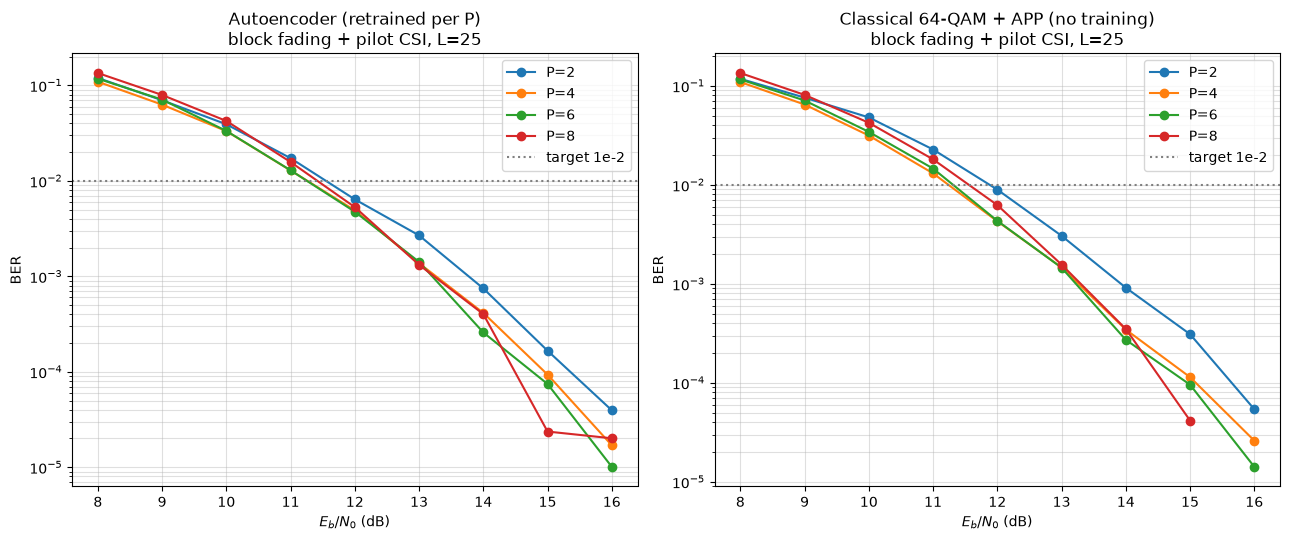

Eb/N0 at BER 1e-2 (lower is better):
  autoencoder P=2  : 11.55 dB
  autoencoder P=4  : 11.26 dB
  autoencoder P=6  : 11.25 dB
  autoencoder P=8  : 11.42 dB


In [36]:
ncols = 2 if BER_final_classical else 1
fig, axes = plt.subplots(1, ncols, figsize=(6.5 * ncols, 5.5), squeeze=False)
panels = [('Autoencoder (retrained per P)', BER_final)]
if BER_final_classical:
    panels.append(('Classical 64-QAM + APP (no training)', BER_final_classical))

for ax, (title, curves) in zip(axes[0], panels):
    for label, ber in curves.items():
        ber = np.asarray(ber)
        msk = ber > 0
        ax.semilogy(ebno_dbs_final[msk], ber[msk], marker='o', label=label)
    ax.axhline(1e-2, color='gray', ls=':', label='target 1e-2')
    ax.set_xlabel(r'$E_b/N_0$ (dB)'); ax.set_ylabel('BER')
    ax.grid(which='both', alpha=0.4); ax.legend()
    ax.set_title(f'{title}\nblock fading + pilot CSI, L=25')

plt.tight_layout()
plt.savefig('ber_vs_P_retrained.png', dpi=150)
plt.show()

# where do the curves actually cross? report it instead of eyeballing the figure.
print("Eb/N0 at BER 1e-2 (lower is better):")
for label, ber in BER_final.items():
    s = snr_at_ber(ebno_dbs_final, ber, 1e-2)
    print(f"  autoencoder {label:<5}: {s:.2f} dB" if not np.isnan(s)
          else f"  autoencoder {label:<5}: not crossed in range")

## 14. CNN vs MLP demapper

**Question:** does a receptive field over neighbouring symbols help?

**Answer: no.** The curves nearly overlap, with the MLP marginally better at high SNR. After
equalisation, flat block fading reduces to a *per-symbol* AWGN channel — neighbours share only
`h_hat`, which is already an input channel. The optimal demapper here is per-symbol, which the
MLP already matches. A CNN's advantage would require a frequency-selective (multipath / OFDM)
channel — which makes OFDM the natural next step.

Both systems are run at P = 2. Section 13 shows there is no globally optimal P, so P = 2 is a
fixed operating point chosen for the comparison, not a claim that it is best; what matters is
that MLP and CNN see the identical configuration. Note that the 8–16 dB comparison range spans
the pilot-count crossover, so the *absolute* level of these curves is not the point — the
MLP-vs-CNN difference at matched P is.

In [37]:
set_seed(42)
mc = E2ESystemPilotCNN(P=2, L=25, training=False, perfect_csi=False).to(device)
ebno = torch.tensor(12.0, device=device)
b, b_hat = mc(64, ebno)
print("b:", b.shape, "b_hat:", b_hat.shape)   # expect [64,750] [64,750]
print("forward pass OK")

b: torch.Size([64, 750]) b_hat: torch.Size([64, 750])
forward pass OK


In [38]:
# train CNN demapper at P=2 (from scratch: the AWGN weights are MLP-shaped and do not transfer)
set_seed(42)
model_cnn = E2ESystemPilotCNN(P=2, L=25, training=True, perfect_csi=False).to(device)

# more steps than the MLP retraining, which starts from AWGN weights rather than from scratch
hist_cnn = train(model_cnn, 4000, rayleigh_ebno_db_min, rayleigh_ebno_db_max, label='CNN  ')
save_weights(model_cnn, 'rayleigh_cnn_P2_weights')



print(f"CNN  validation BCE: {eval_bce(model_cnn, rayleigh_ebno_db_min, rayleigh_ebno_db_max):.4f}")

  CNN  it 4000/4000: BCE(smoothed)=0.2467
CNN  validation BCE: 0.2456


In [39]:
print("=== CNN P=2 ===")
for ebno in [10.0, 14.0, 18.0]:
    set_seed(42)
    m = E2ESystemPilotCNN(P=2, L=25, training=False, perfect_csi=False).to(device)
    load_weights(m, 'rayleigh_cnn_P2_weights')
    with torch.no_grad():
        ber, _ = sim_ber(m, np.array([ebno]), batch_size=256,
                         num_target_block_errors=500, max_mc_iter=200)
    print(f"ebno={ebno}: BER={ber.item():.4e}")

=== CNN P=2 ===
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 4.3131e-02 | 3.9687e-01 |       41406 |      960000 |          508 |        1280 |         6.7 |reached target block errors
ebno=10.0: BER=4.3131e-02
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     14.0 | 9.0142e-04 | 1.1933e-02 |       28384 |    31488000 |          501 |       41984 |       217.5 |reached target block errors
ebno=14.0: BER=9.0142e-04
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
-------------------------------

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      8.0 | 1.1951e-01 | 8.2292e-01 |       34420 |      288000 |          316 |         384 |         1.7 |reached target block errors
      9.0 | 6.9804e-02 | 5.7500e-01 |       33506 |      480000 |          368 |         640 |         2.8 |reached target block errors
     10.0 | 3.9104e-02 | 3.6496e-01 |       26278 |      672000 |          327 |         896 |         4.1 |reached target block errors
     11.0 | 1.7263e-02 | 1.8527e-01 |       23201 |     1344000 |          332 |        1792 |         7.7 |reached target block errors
     12.0 | 6.3939e-03 | 7.3486e-02 |       19642 |     3072000 |          301 |        4096 |        17.7 |reached target block errors
     13.0 | 2.6810e-03 | 3.3312e-02 |       18531 |     6912000 |

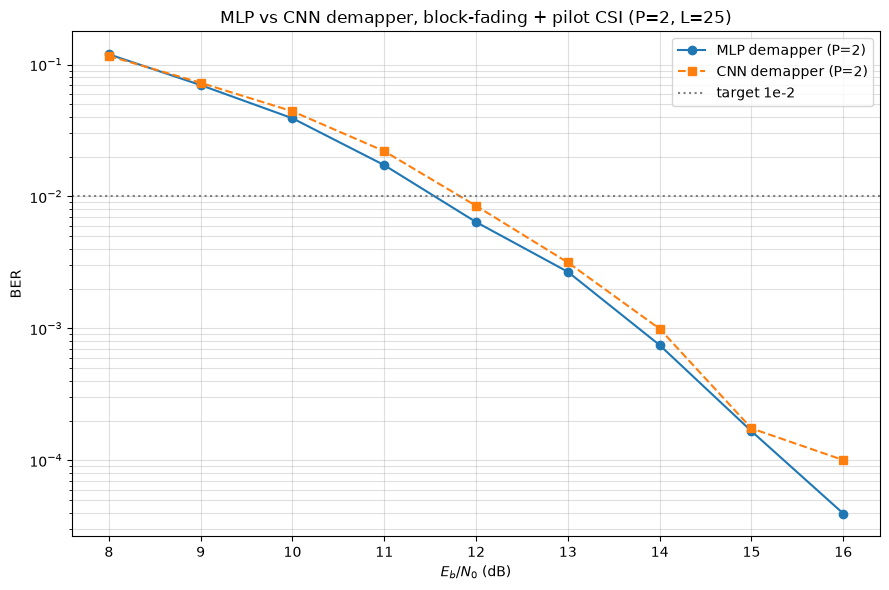

In [40]:
ebno_cmp = np.arange(8.0, 16.1, 1.0)

# MLP (P=2) -- loaded by filename so this cell does not depend on Section 13 still being in memory
set_seed(42)
m_mlp = E2ESystemPilotCSI(P=2, L=25, training=False, perfect_csi=False).to(device)
load_weights(m_mlp, 'rayleigh_pilot_weights_P2')
with torch.no_grad():
    ber_mlp, _ = sim_ber(m_mlp, ebno_cmp, batch_size=128,
                         num_target_block_errors=300, max_mc_iter=100)

# CNN (P=2), same channel realisations
set_seed(42)
m_cnn = E2ESystemPilotCNN(P=2, L=25, training=False, perfect_csi=False).to(device)
load_weights(m_cnn, 'rayleigh_cnn_P2_weights')
with torch.no_grad():
    ber_cnn, _ = sim_ber(m_cnn, ebno_cmp, batch_size=128,
                         num_target_block_errors=300, max_mc_iter=100)

ber_mlp = ber_mlp.cpu().numpy()
ber_cnn = ber_cnn.cpu().numpy()

n_mlp = sum(p.numel() for p in m_mlp._demapper.parameters())
n_cnn = sum(p.numel() for p in m_cnn._demapper.parameters())
print(f"demapper parameters: MLP {n_mlp}  |  CNN {n_cnn}  ({n_cnn / n_mlp:.1f}x)")
for target in (1e-2, 1e-3):
    s_m, s_c = snr_at_ber(ebno_cmp, ber_mlp, target), snr_at_ber(ebno_cmp, ber_cnn, target)
    if not (np.isnan(s_m) or np.isnan(s_c)):
        print(f"BER {target:.0e}: MLP {s_m:.2f} dB | CNN {s_c:.2f} dB | CNN advantage {s_m - s_c:+.2f} dB")

plt.figure(figsize=(9, 6))
msk = ber_mlp > 0
plt.semilogy(ebno_cmp[msk], ber_mlp[msk], 'o-', label='MLP demapper (P=2)')
msk = ber_cnn > 0
plt.semilogy(ebno_cmp[msk], ber_cnn[msk], 's--', label='CNN demapper (P=2)')
plt.axhline(1e-2, color='gray', ls=':', label='target 1e-2')
plt.xlabel(r'$E_b/N_0$ (dB)')
plt.ylabel('BER')
plt.grid(which='both', alpha=0.4)
plt.legend()
plt.title('MLP vs CNN demapper, block-fading + pilot CSI (P=2, L=25)')
plt.tight_layout()
plt.savefig('ber_mlp_vs_cnn.png', dpi=150)
plt.show()

## 15. Capacity study: is 128 hidden units too large?  *(~25 min)*

**Question:** the tutorial defaults to 128 hidden units — is that overkill?

**Answer: partly. The knee is at 64, not lower.** Measured with `eval_bce()` over 32 fixed, seeded
batches (run 2026-08-20):

| width | demapper params | validation BCE | BER @ 5 dB | BER @ 6 dB |
|---|---|---|---|---|
| 16 | 438 | 0.2963 | 4.70e-2 | 9.80e-4 |
| 32 | 1382 | 0.2977 | 2.84e-2 | 2.57e-4 |
| **64** | **4806** | **0.2870** | 2.45e-2 | 2.91e-4 |
| 128 | 17798 | 0.2869 | 2.31e-2 | 2.27e-4 |

Width 64 is indistinguishable from 128 (0.2870 vs 0.2869) at **27% of the parameters**, so the
tutorial default is roughly 4× larger than it needs to be. But 32 is *not* a free lunch: it sits
0.0108 behind, and the entire spread across all four widths is 0.0107 — in other words the whole
effect is the single 32 → 64 step, and 16 and 32 are indistinguishable from each other.

This revises an earlier version of this section, which reported that width 32 nearly matched 128.
That conclusion came from reading `loss.item()` off the final training step, whose single-batch
noise is comparable to the effect being measured. `eval_bce()` was added precisely to settle
questions this size, and it changed the answer.

Either way the point about Section 11 stands, and 11c has now confirmed it directly: capacity was
never the problem. Width 64 already saturates the task, so the Rayleigh failure had to lie in the
input distribution — which is exactly where the intervention experiment found it.

In [41]:
# ============================================================
# Width sweep: is 128 hidden units overkill?
# Train the SAME task (AWGN) at width 16/32/64/128, then compare converged
# validation BCE, parameter count, and BER at a few SNR points.
# ============================================================
widths = [16, 32, 64, 128]
sweep_iters = 5000          # half the original 10000: enough to see convergence, much faster
eval_ebno = np.array([5.0, 6.0, 7.0])   # three points in the AWGN waterfall
results = {}

for w in widths:
    print(f"===== width={w} =====")
    set_seed(42)                                    # same seed for a fair comparison
    model = E2ESystemConventionalTraining(training=True, width=w).to(device)
    train(model, sweep_iters, ebno_db_min, ebno_db_max, clip=None,
          log_every=2000, label=f'w={w}  ')

    # converged loss on a fixed seeded set of batches, not one noisy training step
    final_bce = eval_bce(model, ebno_db_min, ebno_db_max)
    n_params = sum(p.numel() for p in model._demapper.parameters())

    wpath = f'awgn_width{w}_weights'
    save_weights(model, wpath)

    set_seed(42)
    me = E2ESystemConventionalTraining(training=False, width=w).to(device)
    load_weights(me, wpath)
    with torch.no_grad():
        ber, _ = sim_ber(me, eval_ebno, batch_size=128,
                         num_target_block_errors=300, max_mc_iter=100)
    results[w] = {'bce': final_bce, 'params': n_params, 'ber': ber.cpu().numpy()}
    print(f"  width={w}: params={n_params}, validation BCE={final_bce:.4f}")

# ============ summary ============
print("\n================= SUMMARY =================")
print(f"{'width':>6} | {'params':>7} | {'BCE':>7} | {'BER@5dB':>10} | {'BER@6dB':>10} | {'BER@7dB':>10}")
for w in widths:
    r = results[w]
    print(f"{w:>6} | {r['params']:>7} | {r['bce']:.4f} | "
          f"{r['ber'][0]:.3e} | {r['ber'][1]:.3e} | {r['ber'][2]:.3e}")
spread = max(r['bce'] for r in results.values()) - min(r['bce'] for r in results.values())
print(f"\nBCE spread across widths: {spread:.4f}")

===== width=16 =====
  w=16  it 5000/5000: BCE(smoothed)=0.2972
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      5.0 | 4.6945e-02 | 7.5195e-01 |       18027 |      384000 |          385 |         512 |         2.1 |reached target block errors
      6.0 | 9.8014e-04 | 3.6743e-02 |        6022 |     6144000 |          301 |        8192 |        34.7 |reached target block errors
      7.0 | 1.0417e-07 | 7.8125e-05 |           1 |     9600000 |            1 |       12800 |        54.9 |reached max iterations
  width=16: params=438, validation BCE=0.2963
===== width=32 =====
  w=32  it 5000/5000: BCE(smoothed)=0.2981
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
-------------------------------------------------

## 16. Where does 1e-5 come from? Coded vs uncoded  *(~15 min)*

**Question:** 1e-5 on Rayleigh with estimated CSI looks too good — is channel state leaking
into the transmitter?

**Answer: no leak — it is LDPC coding gain.** The uncoded system, using the *same* demapper
weights and the *same* channel, never drops below 2e-2 even at 20 dB. The entire gap between
the two curves is coding gain. The commonly quoted 1e-2/1e-3 figure for estimated CSI refers to
*uncoded* transmission — exactly what the red curve reproduces.

Note: the uncoded curve has BLER = 1 throughout (a 1500-bit block with 2% BER always contains
errors), so `sim_ber` terminates early and its sample size is smaller. This does not affect a
conclusion drawn across three orders of magnitude.

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      4.0 | 2.0062e-01 | 1.0000e+00 |      115557 |      576000 |          384 |         384 |         0.1 |reached target block errors
      6.0 | 1.6038e-01 | 1.0000e+00 |       92381 |      576000 |          384 |         384 |         0.0 |reached target block errors
      8.0 | 1.2491e-01 | 1.0000e+00 |       71948 |      576000 |          384 |         384 |         0.0 |reached target block errors
     10.0 | 9.7498e-02 | 1.0000e+00 |       56159 |      576000 |          384 |         384 |         0.1 |reached target block errors
     12.0 | 6.9333e-02 | 1.0000e+00 |       39936 |      576000 |          384 |         384 |         0.1 |reached target block errors
     14.0 | 4.7399e-02 | 1.0000e+00 |       27302 |      576000 |

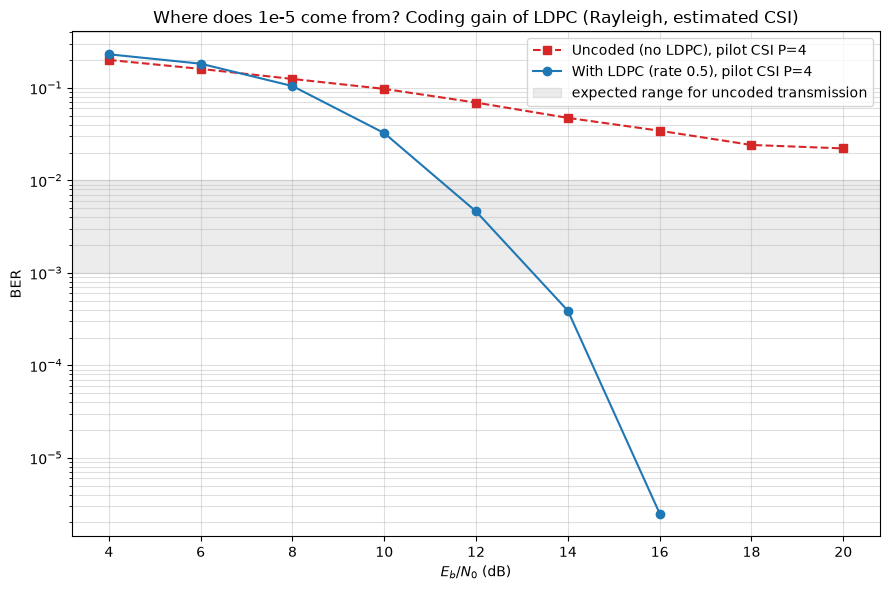

In [42]:
ebno_wide = np.arange(4.0, 20.1, 2.0)

# 1) uncoded + neural demapper (P=4 retrained weights)
set_seed(42)
mu = E2ESystemPilotUncoded(P=4, L=25, training=False, perfect_csi=False).to(device)
load_weights(mu, 'rayleigh_pilot_weights_P4')
with torch.no_grad():
    ber_unc, _ = sim_ber(mu, ebno_wide, batch_size=128,
                         num_target_block_errors=300, max_mc_iter=100)

# 2) the full system with LDPC (same weights, same channel)
set_seed(42)
mc = E2ESystemPilotCSI(P=4, L=25, training=False, perfect_csi=False).to(device)
load_weights(mc, 'rayleigh_pilot_weights_P4')
with torch.no_grad():
    ber_cod, _ = sim_ber(mc, ebno_wide, batch_size=128,
                         num_target_block_errors=300, max_mc_iter=100)

# ============ plot ============
plt.figure(figsize=(9, 6))
b = ber_unc.cpu().numpy(); m = b > 0
plt.semilogy(ebno_wide[m], b[m], 's--', color='C3',
             label='Uncoded (no LDPC), pilot CSI P=4')
b = ber_cod.cpu().numpy(); m = b > 0
plt.semilogy(ebno_wide[m], b[m], 'o-', color='C0',
             label='With LDPC (rate 0.5), pilot CSI P=4')
plt.axhspan(1e-3, 1e-2, color='gray', alpha=0.15,
            label='expected range for uncoded transmission')
plt.xlabel(r'$E_b/N_0$ (dB)')
plt.ylabel('BER')
plt.grid(which='both', alpha=0.4)
plt.legend()
plt.title('Where does 1e-5 come from? Coding gain of LDPC (Rayleigh, estimated CSI)')
plt.tight_layout()
plt.savefig('ber_coded_vs_uncoded.png', dpi=150)
plt.show()

## 17. Does the training-SNR strategy matter?  *(~20 min)*

**Question:** train at a fixed mid SNR, or over a range?

**Answer: almost no difference.** Fixed 15 dB, uniform 8-16 dB and uniform 0-20 dB give
overlapping curves across the whole 0-20 dB evaluation range.

**Why:** `log10(N0)` is an *explicit input*, so the network learns a family of functions
conditioned on noise power rather than a single fixed-SNR demapper. Rayleigh deep fades also
spread the *effective* SNR across orders of magnitude even when the nominal SNR is fixed. This
is the mirror image of Section 11: there the network had never seen the range; here it always
has.

*Caveat: this conclusion depends on N0 being an input. A design without it would be far more
sensitive to the training SNR.*

===== training: fixed 15 dB =====
  fixed 15 dB  it 3000/3000: BCE(smoothed)=0.1480
  validation BCE (over 0-20 dB): 0.2993
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 3.0173e-01 | 1.0000e+00 |       86897 |      288000 |          384 |         384 |         1.5 |reached target block errors
      2.0 | 2.6841e-01 | 1.0000e+00 |       77301 |      288000 |          384 |         384 |         1.6 |reached target block errors
      4.0 | 2.3179e-01 | 1.0000e+00 |       66755 |      288000 |          384 |         384 |         1.6 |reached target block errors
      6.0 | 1.8944e-01 | 9.8698e-01 |       54559 |      288000 |          379 |         384 |         1.6 |reached target block errors
      8.0 | 1.0449e-01 | 7.5195e-01 |       40125 |      384000 |          38

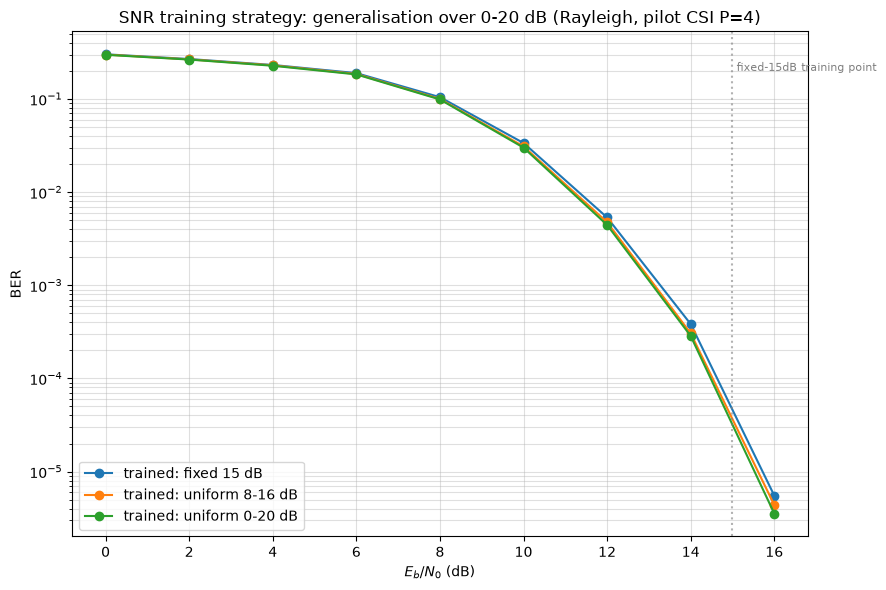

In [43]:
# ============================================================
# SNR training strategy comparison
# A: fixed 15 dB | B: uniform 8-16 dB (current) | C: uniform 0-20 dB
# All evaluated over the full 0-20 dB range.
# ============================================================
strategies = {
    'fixed 15 dB':      (15.0, 15.0),
    'uniform 8-16 dB':  ( 8.0, 16.0),
    'uniform 0-20 dB':  ( 0.0, 20.0),
}
ebno_eval = np.arange(0.0, 20.1, 2.0)
BER_snr = {}

for name, (lo, hi) in strategies.items():
    print(f"===== training: {name} =====")
    set_seed(42)                                                 # identical starting point
    mt = E2ESystemPilotCSI(P=4, L=25, training=True, perfect_csi=False).to(device)
    load_weights(mt, model_weights_path_conventional_training)   # warm-start from AWGN
    train(mt, rayleigh_training_iterations, lo, hi, log_every=1500, label=f'{name}  ')
    wpath = 'snrstrat_' + name.replace(' ', '_').replace('-', '_')
    save_weights(mt, wpath)
    print(f"  validation BCE (over 0-20 dB): {eval_bce(mt, 0.0, 20.0):.4f}")

    set_seed(42)
    me = E2ESystemPilotCSI(P=4, L=25, training=False, perfect_csi=False).to(device)
    load_weights(me, wpath)
    with torch.no_grad():
        ber, _ = sim_ber(me, ebno_eval, batch_size=128,
                         num_target_block_errors=300, max_mc_iter=100)
    BER_snr[name] = ber.cpu().numpy()
    print(f"--- {name} evaluated ---")

# ============ plot ============
plt.figure(figsize=(9, 6))
for name, ber in BER_snr.items():
    ber = np.asarray(ber); m = ber > 0
    plt.semilogy(ebno_eval[m], ber[m], marker='o', label=f'trained: {name}')
plt.axvline(15.0, color='gray', ls=':', alpha=0.6)
plt.text(15.1, 2e-1, 'fixed-15dB training point', fontsize=8, color='gray')
plt.xlabel(r'$E_b/N_0$ (dB)')
plt.ylabel('BER')
plt.grid(which='both', alpha=0.4)
plt.legend()
plt.title('SNR training strategy: generalisation over 0-20 dB (Rayleigh, pilot CSI P=4)')
plt.tight_layout()
plt.savefig('ber_snr_strategy.png', dpi=150)
plt.show()

## Next steps

1. **OFDM extension** — prerequisite for multipath channels (TDL / CDL, `CIRDataset`) and the
   regime where a CNN demapper could actually pay off.
2. **MMSE equalisation** — the notebook uses zero-forcing, so `no_eff` ranges over orders of
   magnitude and carries the demapper's input far outside the range it was trained on, which is
   the mechanism 11c identifies. `conj(h_hat)*y / (|h_hat|^2 + N0)` is bounded by construction and
   compresses that range, so it attacks the cause directly — not the deep-fade tail, which 11c
   ruled out by showing that erasing those symbols makes high SNR *worse*.
3. **Ablate the `log10(N0)` input** — Section 17 concludes that the training-SNR strategy does not
   matter *because* N0 is an explicit input, but that explanation is untested. Rebuilding
   `NeuralDemapper` with a 2-input layer and repeating Section 17 would confirm or refute it, in
   the same style as Section 11c.
4. **Semi-blind estimation** — let the demapper refine `h_hat` using data symbols, not pilots alone.
5. **Extend the error accounting to the remaining curves** — the two poster cells already report
   the accumulated block-error count per point (`precision_table`) and drop anything below 30
   errors before measuring or drawing. Every other section still runs at 300 block errors / 100
   batches and plots whatever comes out, so their lowest points rest on far fewer errors than the
   rest without saying so. Giving them the same treatment — or drawing error bars — would make
   clear which points can carry a conclusion.
6. **Remaining ablations** — activation variants, dropout / normalisation. Huber loss is expected
   *not* to help the demapper (the BCE gradient w.r.t. the logit is already bounded in [-1, 1]);
   it would be the right tool only for a dedicated channel-estimation head regressing on `h`.